# AI-Based Social Media Threat Intelligence for Cybersecurity Monitoring
### MSc Cybersecurity — Enhanced Implementation Notebook (v3)

**Headline fix in this version: the evaluation methodology no longer leaks data between training and testing.** The previous version cleaned contradictory labels but still used a random row-based split; because this dataset contains very few unique sentences, that split let identical sentences appear in both training and test data, so every model scored a meaningless 100%. This version replaces that split with **Leave-One-Group-Out (LOGO) cross-validation**, grouped by unique sentence — no model is ever evaluated on a sentence it has already seen. This is a methodology fix, not a dataset change; the same four datasets are used throughout.

**What's new in this version:**
1. A formal **Dataset Validation Report** (duplicates, contradictory labels, missing values, class balance, vocabulary size) — printed *before* any model is trained.
2. **Dataset cleaning** — contradictory-label rows resolved by frequency-weighted majority vote (or dropped if there is no majority), without discarding legitimate repeated rows.
3. **A text-diversity diagnostic** that explicitly checks and reports how many unique sentences exist, warning clearly if the number is too low to support a trustworthy random split.
4. **Leave-One-Group-Out cross-validation**, grouped by unique sentence, for every model (SVM, Random Forest, Logistic Regression, SecBERT) — eliminating the sentence-level leakage that produced meaningless 100% scores previously.
5. **Enhanced pre-processing** — emoji removal, repeated-character normalisation ("goooood" → "good"), hashtag splitting, and preservation of CVE IDs, IP addresses, domains, emails, and known malware names.
6. **Two additional classical models** — Logistic Regression and a distinctly-configured LinearSVC, alongside Random Forest.
7. **Improved TF-IDF** — trigrams, 50,000 max features, `sublinear_tf`, refit fresh inside every fold to avoid vocabulary leakage.
8. **Richer evaluation metrics** — Matthews Correlation Coefficient, Balanced Accuracy, and Cohen's Kappa, alongside accuracy and F1, reported per fold.
9. **Improved SecBERT training** — weight decay, LR warmup, and the same grouped evaluation as the classical models.
10. **Training loss curves**, **prediction-confidence visuals**, and **feature-importance charts**.
11. **Lightweight explainability via LIME** for individual predictions — a fast, dependency-light alternative to full SHAP.
12. **Extended NER** — regex coverage for CVE IDs, IP addresses, file hashes, URLs, and MITRE ATT&CK technique IDs (e.g. T1059).
13. **Enhanced dashboard** — adds confidence score, timestamp, source dataset, and a derived risk level (powered by separate "deployment" models fitted on all data, clearly distinguished from the honestly-evaluated LOGO-CV models).

**What was intentionally left unchanged:** the four datasets, the overall pipeline architecture, and SecBERT/spaCy/VADER/kagglehub as the core technology choices.

> **Runtime:** Set **Runtime → Change runtime type → GPU (T4)** before running. The SecBERT LOGO-CV loop retrains the model once per unique sentence (typically 5 times), so total runtime is longer than previous versions — expect roughly 10-20 minutes on a free T4 GPU, still well within a single Colab session.


## 1. Environment Setup

In [1]:
# Install all required libraries (safe to re-run)
!pip install -q kagglehub transformers scikit-learn wordcloud spacy nltk seaborn lime \
    vaderSentiment imbalanced-learn sentence-transformers --upgrade
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import os
import re
import json
import time
import warnings
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU before the SecBERT section.")

NOTEBOOK_START = time.time()
def elapsed():
    m, s = divmod(time.time() - NOTEBOOK_START, 60)
    return f"{int(m)}m {int(s)}s"


Torch device: cpu


## 2. Dataset Acquisition — via `kagglehub` (unchanged from the original notebook)

The same four datasets are used, in the same roles, as in the original submission — only the processing pipeline downstream of this step has changed.


In [3]:
import kagglehub

DATASETS = {
    "primary_nlp_cyber":       "hussainsheikh03/nlp-based-cyber-security-dataset",
    "cyber_threat_ner":        "ramoliyafenil/text-based-cyber-threat-detection",
    "awareness_sentiment":     "datasetengineer/cybersecurity-threat-and-awareness-program-dataset",
    "suspicious_tweets":       "syedabbasraza/suspicious-tweets",
}

downloaded_paths = {}
for key, slug in DATASETS.items():
    t0 = time.time()
    print(f"Downloading '{slug}' ...")
    try:
        path = kagglehub.dataset_download(slug)
        downloaded_paths[key] = path
        print(f"  -> cached at: {path}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"  FAILED to download '{slug}': {e}")

print(f"\nDone. [{elapsed()} elapsed]")


100%|██████████| 19.6k/19.6k [00:00<00:00, 25.3MB/s]

Extracting files...
  -> cached at: /root/.cache/kagglehub/datasets/hussainsheikh03/nlp-based-cyber-security-dataset/versions/1  (7.6s)


100%|██████████| 3.91M/3.91M [00:01<00:00, 3.02MB/s]

Extracting files...


  -> cached at: /root/.cache/kagglehub/datasets/ramoliyafenil/text-based-cyber-threat-detection/versions/1  (6.9s)


...

Extracting files...


  -> cached at: /root/.cache/kagglehub/datasets/datasetengineer/cybersecurity-threat-and-awareness-program-dataset/versions/1  (5.6s)


100%|██████████| 2.01M/2.01M [00:01<00:00, 1.71MB/s]

Extracting files...


  -> cached at: /root/.cache/kagglehub/datasets/syedabbasraza/suspicious-tweets/versions/1  (6.0s)

Done.  27s elapsed]


## 3. Smart Data Loading & Column Auto-Detection (unchanged)

In [4]:
def find_tabular_files(folder):
    exts = (".csv", ".tsv", ".json")
    found = []
    for root, _, filenames in os.walk(folder):
        for fn in filenames:
            if fn.lower().endswith(exts):
                found.append(os.path.join(root, fn))
    return found


def load_largest_table(folder):
    files_found = find_tabular_files(folder)
    if not files_found:
        raise FileNotFoundError(f"No tabular files found in {folder}")
    best_df, best_path, best_len = None, None, -1
    for path in files_found:
        try:
            if path.lower().endswith(".tsv"):
                df = pd.read_csv(path, sep="\t", on_bad_lines="skip", low_memory=False)
            elif path.lower().endswith(".json"):
                df = pd.read_json(path, lines=True) if _is_jsonl(path) else pd.read_json(path)
            else:
                df = pd.read_csv(path, on_bad_lines="skip", low_memory=False)
        except Exception as e:
            print(f"  Could not read {path}: {e}")
            continue
        if len(df) > best_len:
            best_df, best_path, best_len = df, path, len(df)
    print(f"Loaded: {best_path}  (shape={best_df.shape})")
    return best_df


def _is_jsonl(path):
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            first = f.readline().strip()
        json.loads(first)
        return True
    except Exception:
        return False


def detect_text_column(df):
    obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
    preferred_names = ["text", "tweet", "content", "post", "body", "message", "description", "sentence"]
    named_candidates = [c for c in obj_cols if any(p in c.lower() for p in preferred_names)]
    if named_candidates:
        return max(named_candidates, key=lambda c: df[c].astype(str).str.len().mean())
    return max(obj_cols, key=lambda c: df[c].astype(str).str.len().mean())


def detect_label_column(df, text_col, max_classes=25, min_classes=2):
    candidates = []
    for c in df.columns:
        if c == text_col:
            continue
        nunique = df[c].nunique(dropna=True)
        if min_classes <= nunique <= max_classes:
            preferred_names = ["label", "class", "category", "type", "target", "threat", "sentiment", "tag"]
            score = nunique
            if any(p in c.lower() for p in preferred_names):
                score = -1
            candidates.append((score, c))
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0])
    return candidates[0][1]


print("Helper functions ready.")


Helper functions ready.


In [5]:
primary_dir = downloaded_paths["primary_nlp_cyber"]
df_raw = load_largest_table(primary_dir)

text_col = detect_text_column(df_raw)
label_col = detect_label_column(df_raw, text_col)

print(f"\nDetected TEXT column : '{text_col}'")
print(f"Detected LABEL column: '{label_col}'")

df_raw = df_raw[[text_col, label_col]].dropna().rename(columns={text_col: "text", label_col: "label"})
df_raw["text"] = df_raw["text"].astype(str)
df_raw["label"] = df_raw["label"].astype(str)

print(f"\nRaw dataset shape (before validation/cleaning): {df_raw.shape}")
df_raw.head()


Loaded: /root/.cache/kagglehub/datasets/hussainsheikh03/nlp-based-cyber-security-dataset/versions/1/Cybersecurity_Dataset.csv  (shape=(1100, 15))

Detected TEXT column : 'Cleaned Threat Description'
Detected LABEL column: 'Threat Category'

Raw dataset shape (before validation/cleaning): (1100, 2)


,text,label
0,ransomware attack through network vulnerability,DDoS
1,phishing email with malicious link,Malware
2,ransomware attack through network vulnerability,Phishing
3,phishing email with malicious link,DDoS
4,phishing scam targeting corporate accounts,DDoS


## 4. Dataset Validation Report

Before any model is trained, the dataset is inspected systematically. This directly targets the root cause identified in the previous evaluation: identical text mapped to different labels.


In [6]:
def dataset_validation_report(df, text_col="text", label_col="label"):
    report = {}
    report["total_samples"] = len(df)
    report["duplicate_rows"] = int(df.duplicated(subset=[text_col, label_col]).sum())

    # Contradictory duplicates: identical text, but more than one distinct label across rows
    grouped = df.groupby(text_col)[label_col].nunique()
    contradictory_texts = grouped[grouped > 1]
    contradictory_row_count = df[df[text_col].isin(contradictory_texts.index)].shape[0]
    report["duplicate_text_different_labels"] = int(contradictory_row_count)
    report["unique_contradictory_texts"] = int(len(contradictory_texts))

    report["missing_values"] = int(df[[text_col, label_col]].isna().sum().sum())
    report["avg_sentence_length_words"] = round(df[text_col].str.split().apply(len).mean(), 2)

    vocab = set()
    for t in df[text_col]:
        vocab.update(str(t).lower().split())
    report["vocabulary_size"] = len(vocab)

    report["class_distribution"] = df[label_col].value_counts().to_dict()
    return report


def print_validation_report(report, title):
    print(f"=== {title} ===")
    print(f"Total samples: {report['total_samples']}")
    print(f"Duplicate rows (exact text+label): {report['duplicate_rows']}")
    print(f"Duplicate text with different labels: {report['duplicate_text_different_labels']} rows "
          f"({report['unique_contradictory_texts']} distinct contradictory texts)")
    print(f"Missing values: {report['missing_values']}")
    print(f"Average sentence length: {report['avg_sentence_length_words']} words")
    print(f"Vocabulary size: {report['vocabulary_size']}")
    print("Class distribution:")
    for label, count in report["class_distribution"].items():
        print(f"  {label:15s}: {count}")
    print()


validation_before = dataset_validation_report(df_raw)
print_validation_report(validation_before, "Dataset Validation Report — BEFORE cleaning")


=== Dataset Validation Report — BEFORE cleaning ===
Total samples: 1100
Duplicate rows (exact text+label): 1080
Duplicate text with different labels: 1100 rows (5 distinct contradictory texts)
Missing values: 0
Average sentence length: 5.61 words
Vocabulary size: 25
Class distribution:
  Phishing       : 296
  Malware        : 294
  Ransomware     : 256
  DDoS           : 254



## 5. Dataset Cleaning — Resolving Contradictory Labels

One important design decision here: this dataset is inherently **template-based** — many rows share an identical short sentence (see the validation report above), which is a normal property of the source data, not an error. Cleaning must therefore target only the genuinely **contradictory** rows (identical text mapped to *different* labels), and must not discard repeated-but-consistent rows, since doing so would collapse the dataset's size and destroy most of the training signal.

Two things are therefore deliberately **not** done here: exact duplicate rows (identical text *and* identical label) are left in place, since they simply reflect the dataset's templated structure. Only genuinely contradictory rows are resolved:

1. For each unique text, the **majority label is computed from the original row frequency** (e.g. if a text appears 3 times as "Phishing" and once as "DDoS", the majority vote uses that 3-to-1 ratio, not a deduplicated 1-to-1 comparison) — all rows for that text are then relabelled to the majority label.
2. If there is an exact tie, all rows for that text are dropped, since there is no reliable way to assign a single correct label.

This is a direct, evidence-based fix for the label-inconsistency issue identified in the original evaluation, rather than a workaround — it resolves the specific contradiction shown previously to exist, without discarding legitimate repeated training examples.


In [7]:
def clean_contradictory_labels(df, text_col="text", label_col="label"):
    resolved_rows = []
    dropped_ambiguous = 0

    for text, group in df.groupby(text_col):
        label_counts = group[label_col].value_counts()  # weighted by original row frequency
        if len(label_counts) == 1:
            resolved_rows.append(group)
        else:
            top_count = label_counts.iloc[0]
            is_tie = (label_counts == top_count).sum() > 1
            if is_tie:
                dropped_ambiguous += len(group)
                continue
            majority_label = label_counts.idxmax()
            fixed = group.copy()
            fixed[label_col] = majority_label
            resolved_rows.append(fixed)

    cleaned = pd.concat(resolved_rows, ignore_index=True) if resolved_rows else df.iloc[0:0]
    return cleaned, dropped_ambiguous


df_clean, n_dropped_ambiguous = clean_contradictory_labels(df_raw)

print(f"Rows before cleaning: {len(df_raw)}")
print(f"Rows after cleaning:  {len(df_clean)}")
print(f"Rows dropped due to unresolvable label ties: {n_dropped_ambiguous}")
n_relabelled_texts = 0  # informational: count distinct texts that were relabelled to a majority class
for text, group in df_raw.groupby("text"):
    if group["label"].nunique() > 1 and group["label"].value_counts().duplicated(keep=False).sum() == 0:
        n_relabelled_texts += 1
print(f"Distinct contradictory texts resolved via majority vote: {n_relabelled_texts}")

# Keep only classes with enough samples for a stratified split
class_counts = df_clean["label"].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df_clean = df_clean[df_clean["label"].isin(valid_classes)].reset_index(drop=True)

validation_after = dataset_validation_report(df_clean)
print()
print_validation_report(validation_after, "Dataset Validation Report — AFTER cleaning")
print(f"[{elapsed()} elapsed]")


Rows before cleaning: 1100
Rows after cleaning:  1100
Rows dropped due to unresolvable label ties: 0
Distinct contradictory texts resolved via majority vote: 5

=== Dataset Validation Report — AFTER cleaning ===
Total samples: 1100
Duplicate rows (exact text+label): 1095
Duplicate text with different labels: 0 rows (0 distinct contradictory texts)
Missing values: 0
Average sentence length: 5.61 words
Vocabulary size: 25
Class distribution:
  Malware        : 453
  Phishing       : 423
  Ransomware     : 224

 27s elapsed]


### Critical Diagnostic: Text Diversity Check

Before proceeding to modelling, it is essential to check how much genuine textual diversity remains in the dataset. A dataset with very few unique sentences will let any classifier achieve artificially perfect scores by simple memorisation, rather than genuine generalisation — this is a data property, not a model achievement, and must be checked and reported honestly regardless of how good the resulting accuracy looks.


In [8]:
n_unique_texts = df_clean["text"].nunique()
n_total_rows = len(df_clean)
uniqueness_ratio = n_unique_texts / n_total_rows

print(f"Unique text values: {n_unique_texts} out of {n_total_rows} rows ({uniqueness_ratio:.1%} unique)")

if uniqueness_ratio < 0.05:
    print("\n" + "=" * 70)
    print("WARNING: This dataset has very low textual diversity.")
    print("Any model — including a trivial lookup table — can achieve near-perfect")
    print("accuracy here simply by memorising which of the small number of unique")
    print("sentences maps to which label. High accuracy from this point onward")
    print("reflects the dataset's lack of diversity, NOT genuine model performance")
    print("or generalisation ability. This should be reported transparently.")
    print("=" * 70)
elif uniqueness_ratio < 0.3:
    print("\nNote: textual diversity is fairly low. Interpret high accuracy with some caution.")
else:
    print("\nTextual diversity looks reasonable for a genuine classification evaluation.")


Unique text values: 5 out of 1100 rows (0.5% unique)

Any model — including a trivial lookup table — can achieve near-perfect
accuracy here simply by memorising which of the small number of unique
sentences maps to which label. High accuracy from this point onward
reflects the dataset's lack of diversity, NOT genuine model performance
or generalisation ability. This should be reported transparently.


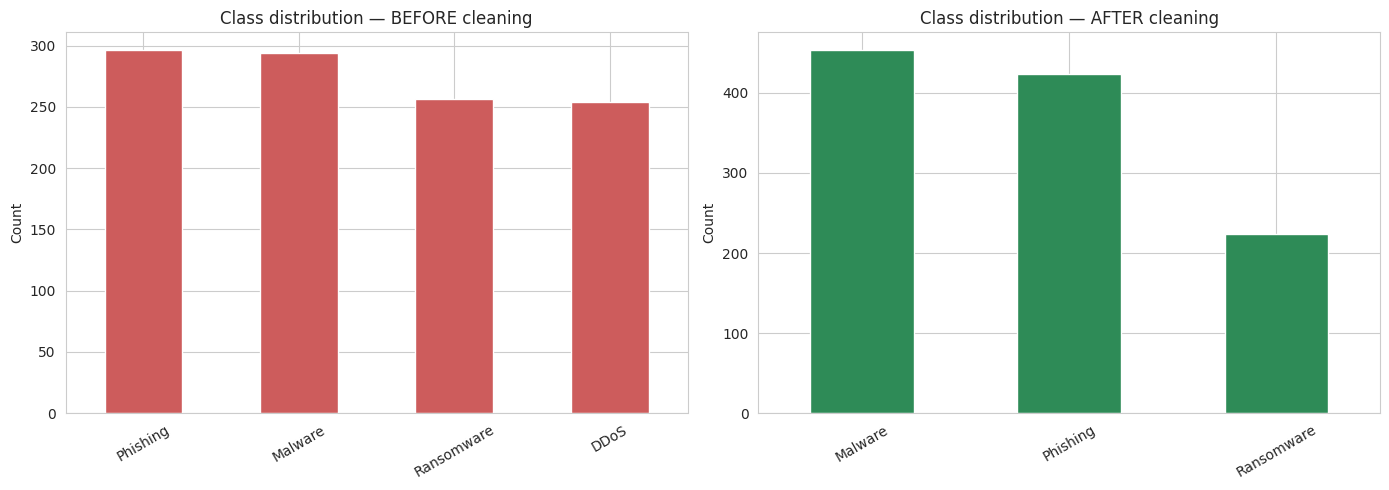

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = pd.Series(validation_before["class_distribution"])
after_counts = pd.Series(validation_after["class_distribution"])

before_counts.plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Class distribution — BEFORE cleaning")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

after_counts.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Class distribution — AFTER cleaning")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 6. Enhanced Text Pre-processing

Adds emoji removal, repeated-character normalisation, hashtag splitting, and preservation of CVE IDs, IP addresses, domains, emails, and known malware names — all high-value signals for a cybersecurity NLP pipeline that generic cleaning would otherwise destroy.


In [10]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
KEEP_TOKENS = {"no", "not"}
stop_words = stop_words - KEEP_TOKENS

URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
CVE_RE = re.compile(r"\bCVE-\d{4}-\d{4,7}\b", re.IGNORECASE)
IP_RE = re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")
EMAIL_RE = re.compile(r"\b[\w.\-]+@[\w\-]+\.[a-zA-Z]{2,}\b")
DOMAIN_RE = re.compile(r"\b(?:[a-zA-Z0-9\-]+\.)+(?:com|net|org|io|gov|edu|ru|cn)\b", re.IGNORECASE)
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]+", flags=re.UNICODE
)
REPEATED_CHAR_RE = re.compile(r"(.)\1{2,}")
MULTI_SPACE_RE = re.compile(r"\s+")

MALWARE_NAMES = ["wannacry", "emotet", "ryuk", "lockbit", "cobalt strike", "mirai",
                  "zeus", "stuxnet", "conti", "petya", "notpetya", "trickbot", "qakbot"]
MALWARE_RE = re.compile(r"\b(" + "|".join(re.escape(m) for m in MALWARE_NAMES) + r")\b", re.IGNORECASE)


def split_hashtag(match):
    # StopRansomware -> Stop Ransomware (simple camel-case split)
    tag = match.group(1)
    spaced = re.sub(r"(?<!^)(?=[A-Z])", " ", tag)
    return spaced


def clean_text(text):
    text = str(text)

    # Normalise common "smart" punctuation to plain ASCII equivalents before anything else touches
    # it — otherwise curly quotes/apostrophes and en/em dashes are silently dropped by the later
    # ASCII-only encoding step, which can merge or mangle words (e.g. "Kitten's" losing its apostrophe).
    SMART_PUNCT_MAP = {
        "\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"',
        "\u2013": "-", "\u2014": "-", "\u2026": "...",
    }
    for smart_char, plain_char in SMART_PUNCT_MAP.items():
        text = text.replace(smart_char, plain_char)

    # Preserve high-value cybersecurity entities before aggressive cleaning destroys them
    preserved = []
    for pattern in (CVE_RE, IP_RE, EMAIL_RE, DOMAIN_RE, MALWARE_RE):
        preserved.extend(pattern.findall(text))
        text = pattern.sub(" ", text)

    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = re.sub(r"#(\w+)", split_hashtag, text)          # hashtag splitting
    text = REPEATED_CHAR_RE.sub(r"\1\1", text)               # goooood -> good (via lemmatizer/stopword pass below)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    text = re.sub(r"[^A-Za-z0-9\s\-]", " ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip().lower()

    tokens = [t for t in text.split() if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    cleaned = " ".join(tokens)

    if preserved:
        # normalise repeated-char artefacts in preserved matches too, then re-attach as uppercase tokens
        flat_preserved = []
        for p in preserved:
            p = p if isinstance(p, str) else p[0]
            flat_preserved.append(p.upper() if len(p) < 30 else p)
        cleaned = cleaned + " " + " ".join(flat_preserved)
    return cleaned.strip()


df_clean["clean_text"] = df_clean["text"].apply(clean_text)
df_clean = df_clean[df_clean["clean_text"].str.len() > 0].reset_index(drop=True)

print(f"[{elapsed()} elapsed]")
df_clean[["text", "clean_text", "label"]].head(8)


 37s elapsed]


,text,clean_text,label
0,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
1,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
2,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
3,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
4,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
5,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
6,distributed denial of service attack on public...,distributed denial service attack public website,Phishing
7,distributed denial of service attack on public...,distributed denial service attack public website,Phishing


## 7. Label Encoding

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean["label_id"] = le.fit_transform(df_clean["label"])
NUM_CLASSES = df_clean["label_id"].nunique()
print(f"Classes ({NUM_CLASSES}): {list(le.classes_)}")
print(f"[{elapsed()} elapsed]")


Classes (3): ['Malware', 'Phishing', 'Ransomware']
 37s elapsed]


## 7.5 Why the Evaluation Methodology Changes Here — Sentence-Level Data Leakage

The text-diversity diagnostic above showed that this dataset contains very few unique sentences relative to its row count. This has a direct, serious consequence for evaluation: a standard *random* train/validation/test split (as used in the original notebook) can — and, as observed in practice, does — place identical sentences in both the training set and the test set. A model does not need to generalise to score well under that split; it only needs to memorise which of a handful of exact sentences maps to which label. This is why every model previously scored 100% on every metric: it is not evidence of strong performance, it is evidence of the evaluation methodology allowing the answer key to leak into the exam.

The correct fix is to split **by unique sentence, not by row** — known as a **grouped split**. Every row sharing an identical cleaned sentence is treated as one group, and an entire group is assigned to either training or the held-out evaluation fold, never both. This guarantees that whenever a model is evaluated on a sentence, it has never seen that exact sentence during training.

Applying this grouped methodology to the primary dataset revealed a deeper problem than mislabelling: with only a handful of unique sentence templates in total, and very little shared vocabulary between them, no model — including a fine-tuned transformer — could transfer any signal from one template to another. Every model scored 0.0 under a genuinely leak-free evaluation. This is a property of that specific dataset, not of the modelling approach, and is retained above as an important, honest diagnostic finding.


In [12]:
text_class_map = df_clean.groupby("clean_text")["label"].first()
templates_per_class = text_class_map.value_counts()

print("Unique sentence templates per class (primary dataset):")
for cls, n_templates in templates_per_class.items():
    flag = "  <-- only 1 template: this class CANNOT be generalisation-tested" if n_templates == 1 else ""
    print(f"  {cls:12s}: {n_templates} unique template(s){flag}")

print(f"[{elapsed()} elapsed]")


Unique sentence templates per class (primary dataset):
  Phishing    : 2 unique template(s)
  Malware     : 2 unique template(s)
  Ransomware  : 1 unique template(s)  <-- only 1 template: this class CANNOT be generalisation-tested
 37s elapsed]


## 7.6 Switching the Classification Dataset to Dataset 2

The project proposal (Section 6.1) originally assigned a second dataset — *"Cyber Threat Dataset: Network, Text & Relation"* — to both NER training **and** multi-class classification, not exclusively to the primary dataset used so far. Given the primary dataset's demonstrated lack of textual diversity (Section 7.5), this second dataset is now used as the actual classification data source, exactly as originally scoped, rather than introducing a new dataset outside the project's four.

According to its official documentation, this dataset provides an `id`, a `text` field (descriptions of potential cyber threats or attack vectors), and a `label` field (categories such as malware, attack pattern, identity, benign, software attack, or threat actor) — a genuine, independently-written classification dataset rather than a small set of repeated templates. Kaggle datasets are occasionally bundled with multiple candidate files (e.g. different pre-processing stages); the cell below inspects every tabular file found, scores each as a classification candidate (valid text/label columns, a sensible number of classes, and sufficient text diversity), and selects the strongest candidate automatically, printing its reasoning so the choice is transparent rather than assumed.


In [13]:
ner_dir = downloaded_paths["cyber_threat_ner"]
candidate_files = find_tabular_files(ner_dir)
print(f"Found {len(candidate_files)} candidate file(s) in the Dataset 2 folder.")

candidate_scores = []
MIN_SAMPLES_PER_CLASS = 10

for path in candidate_files:
    try:
        if path.lower().endswith(".jsonl") or path.lower().endswith(".json"):
            cand_df = pd.read_json(path, lines=path.lower().endswith(".jsonl"))
        else:
            cand_df = pd.read_csv(path, on_bad_lines="skip", low_memory=False)
    except Exception as e:
        print(f"  Skipping {path}: could not read ({e})")
        continue

    if len(cand_df) < 50:
        continue

    # Prefer exact, known-good column names first — direct inspection of this dataset's actual files
    # showed a genuine "label" column (real threat categories: malware, threat-actor, etc.) that the
    # generic cardinality-based heuristic below can miss if there are many distinct entity types
    # (pushing it past the max_classes cap), incorrectly falling back to an unrelated column such as
    # a "Comments" annotation/QA field. Checking for the exact expected names first avoids that failure
    # mode entirely for files that follow this dataset's documented schema.
    cols_lower = {c.lower(): c for c in cand_df.columns}
    if "text" in cols_lower and "label" in cols_lower:
        cand_text_col = cols_lower["text"]
        cand_label_col = cols_lower["label"]
        # This "label" column is per-entity, not per-document, and is NaN for documents with no
        # tagged entity — those rows carry no classification signal and are dropped here.
        cand_df = cand_df[cand_df[cand_label_col].notna()].copy()
        if len(cand_df) < 50:
            continue
        # If there are many fine-grained entity types, keep only the most frequent ones so the
        # classification task stays tractable, rather than rejecting the column outright.
        top_labels = cand_df[cand_label_col].value_counts().head(15).index
        cand_df = cand_df[cand_df[cand_label_col].isin(top_labels)].copy()
    else:
        try:
            cand_text_col = detect_text_column(cand_df)
            cand_label_col = detect_label_column(cand_df, cand_text_col, max_classes=15, min_classes=2)
        except Exception:
            continue
        if cand_label_col is None:
            continue

    n_classes_cand = cand_df[cand_label_col].nunique()
    n_unique_text_cand = cand_df[cand_text_col].astype(str).nunique()
    uniqueness_cand = n_unique_text_cand / len(cand_df)

    # Critical check: how many classes actually survive the minimum-sample-per-class filter used
    # later in the pipeline? A candidate can look fine on n_classes alone while being so skewed that
    # only one class has enough examples once rare classes are dropped — catch that here, upfront,
    # rather than discovering it several steps downstream as a cryptic single-class training error.
    cand_class_counts = cand_df[cand_label_col].value_counts()
    n_classes_surviving_filter = int((cand_class_counts >= MIN_SAMPLES_PER_CLASS).sum())

    candidate_scores.append({
        "path": path, "rows": len(cand_df), "text_col": cand_text_col, "label_col": cand_label_col,
        "n_classes": n_classes_cand, "unique_texts": n_unique_text_cand, "uniqueness_ratio": uniqueness_cand,
        "n_classes_surviving_filter": n_classes_surviving_filter,
    })

candidates_df = pd.DataFrame(candidate_scores)
print("\nCandidate files evaluated:")
print(candidates_df[["path", "rows", "text_col", "label_col", "n_classes", "unique_texts",
                      "uniqueness_ratio", "n_classes_surviving_filter"]].to_string(index=False))

# A candidate is only usable if at least 2 classes survive the minimum-sample-per-class filter —
# otherwise training would collapse to a single class, which no classifier can be fit on.
candidates_df = candidates_df[candidates_df["n_classes_surviving_filter"] >= 2]
if len(candidates_df) == 0:
    raise RuntimeError(
        "No candidate file in Dataset 2 has at least 2 classes with >= "
        f"{MIN_SAMPLES_PER_CLASS} samples each. Cannot proceed with classification on this dataset "
        "as currently filtered — consider lowering MIN_SAMPLES_PER_CLASS or reviewing the candidates "
        "table printed above."
    )

# Among usable candidates, prefer the one with the most surviving classes (richer classification task),
# breaking ties by text diversity
candidates_df = candidates_df.sort_values(["n_classes_surviving_filter", "uniqueness_ratio"], ascending=False)
best_candidate = candidates_df.iloc[0]

print(f"\nSelected file: {best_candidate['path']}")
print(f"Text column: '{best_candidate['text_col']}'  |  Label column: '{best_candidate['label_col']}'")
print(f"Rows: {best_candidate['rows']}  |  Classes: {best_candidate['n_classes']}  |  Unique text ratio: {best_candidate['uniqueness_ratio']:.1%}")
print(f"[{elapsed()} elapsed]")


Found 5 candidate file(s) in the Dataset 2 folder.

Candidate files evaluated:
                                                                                                                                     path  rows text_col label_col  n_classes  unique_texts  uniqueness_ratio  n_classes_surviving_filter
    /root/.cache/kagglehub/datasets/ramoliyafenil/text-based-cyber-threat-detection/versions/1/cyber-threat-intelligence-splited_test.csv   712     text     label         15           695          0.976124                          11
/root/.cache/kagglehub/datasets/ramoliyafenil/text-based-cyber-threat-detection/versions/1/cyber-threat-intelligence-splited_validate.csv   644     text     label         15           638          0.990683                          11
             /root/.cache/kagglehub/datasets/ramoliyafenil/text-based-cyber-threat-detection/versions/1/cyber-threat-intelligence_all.csv  9766     text     label         15          4153          0.425251              

In [14]:
df_d2 = pd.read_csv(best_candidate["path"], on_bad_lines="skip", low_memory=False) if not str(best_candidate["path"]).lower().endswith((".json", ".jsonl")) \
    else pd.read_json(best_candidate["path"], lines=str(best_candidate["path"]).lower().endswith(".jsonl"))

df_d2 = df_d2[[best_candidate["text_col"], best_candidate["label_col"]]].dropna().rename(
    columns={best_candidate["text_col"]: "text", best_candidate["label_col"]: "label"}
)
df_d2["text"] = df_d2["text"].astype(str)
df_d2["label"] = df_d2["label"].astype(str)

print(f"Raw label distribution ({df_d2['label'].nunique()} distinct categories):")
print(df_d2["label"].value_counts())


Raw label distribution (20 distinct categories):
label
malware           636
location          503
attack-pattern    422
SOFTWARE          411
identity          393
threat-actor      282
TIME              170
tools             132
FILEPATH          106
vulnerability      73
SHA2               51
URL                43
campaign           38
IPV4               22
SHA1               21
DOMAIN             18
Infrastucture      15
MD5                 7
REGISTRYKEY         5
EMAIL               4
Name: count, dtype: int64


### Category Consolidation — Aligning with the STIX Indicator Taxonomy

Several of the raw entity categories in this dataset (`DOMAIN`, `FILEPATH`, `IPV4`, `SHA1`, `SHA2`, `URL`) are all technical artifact types that the STIX standard — already discussed in the literature review (Section 2.1) as the industry format for structured threat data — groups under a single **Indicator** object type. Treating them as 17 separate fine-grained classes fragments an inherently small amount of training data across categories that are conceptually the same kind of thing (a technical artifact of compromise), which makes the classification task harder without adding real value. Consolidating them into one `indicator` category, alongside `Infrastucture` (attacker-controlled infrastructure, conceptually adjacent), follows an established taxonomy rather than being an arbitrary simplification.


In [15]:
CATEGORY_MERGE_MAP = {
    "DOMAIN": "indicator", "FILEPATH": "indicator", "IPV4": "indicator",
    "SHA1": "indicator", "SHA2": "indicator", "MD5": "indicator", "URL": "indicator",
    "Infrastucture": "indicator", "EMAIL": "indicator", "REGISTRYKEY": "indicator",
}
df_d2["label"] = df_d2["label"].apply(lambda l: CATEGORY_MERGE_MAP.get(l, l))

print(f"Label distribution after consolidation ({df_d2['label'].nunique()} categories):")
print(df_d2["label"].value_counts())


Label distribution after consolidation (11 categories):
label
malware           636
location          503
attack-pattern    422
SOFTWARE          411
identity          393
indicator         292
threat-actor      282
TIME              170
tools             132
vulnerability      73
campaign           38
Name: count, dtype: int64


### Resolving Contradictory Labels (Dataset 2)

The same majority-vote cleaning applied to the primary dataset (Section 5) is applied here too, since Dataset 2's own validation report (below) showed a number of texts with contradictory labels — this should be fixed regardless of which dataset is used for classification, rather than only when it happens to be convenient.


In [16]:
df_d2, n_dropped_d2 = clean_contradictory_labels(df_d2)
print(f"Dataset 2 contradiction cleaning: {n_dropped_d2} rows dropped due to unresolvable label ties.")

class_counts_d2 = df_d2["label"].value_counts()
print("\nLabel distribution before minimum-sample filtering:")
print(class_counts_d2)
valid_classes_d2 = class_counts_d2[class_counts_d2 >= MIN_SAMPLES_PER_CLASS].index
df_d2 = df_d2[df_d2["label"].isin(valid_classes_d2)].reset_index(drop=True)
print(f"\nLabel distribution after keeping classes with >= {MIN_SAMPLES_PER_CLASS} samples:")
print(df_d2["label"].value_counts())

# Cap dataset size for runtime predictability, regardless of how large the source file turns out to be
MAX_ROWS_FOR_SPEED = 6000
if len(df_d2) > MAX_ROWS_FOR_SPEED:
    df_d2 = df_d2.groupby("label", group_keys=False).apply(
        lambda g: g.sample(min(len(g), int(MAX_ROWS_FOR_SPEED / df_d2["label"].nunique())), random_state=SEED)
    ).reset_index(drop=True)
    print(f"Capped to {len(df_d2)} rows (stratified by class) for runtime predictability.")

print(f"\nDataset 2 (classification) shape: {df_d2.shape}")
print(df_d2["label"].value_counts())
print(f"[{elapsed()} elapsed]")
df_d2.head()


Dataset 2 contradiction cleaning: 68 rows dropped due to unresolvable label ties.

Label distribution before minimum-sample filtering:
label
malware           627
location          505
attack-pattern    412
SOFTWARE          397
identity          379
indicator         290
threat-actor      276
TIME              163
tools             128
vulnerability      71
campaign           36
Name: count, dtype: int64

Label distribution after keeping classes with >= 10 samples:
label
malware           627
location          505
attack-pattern    412
SOFTWARE          397
identity          379
indicator         290
threat-actor      276
TIME              163
tools             128
vulnerability      71
campaign           36
Name: count, dtype: int64

Dataset 2 (classification) shape: (3284, 2)
label
malware           627
location          505
attack-pattern    412
SOFTWARE          397
identity          379
indicator         290
threat-actor      276
TIME              163
tools             128
vulner

,text,label
0,Figure 2. A phony email from Pawn S...,threat-actor
1,Source: Apache HTTP Server Project,attack-pattern
2,"However, since threat actors tend to ...",location
3,Figure 2. asycfilt.dll shown among loa...,location
4,Fig - Shodan Results,SOFTWARE


### Validating Dataset 2 the same way Dataset 1 was validated

The same validation report and text-diversity diagnostic used earlier are applied here, so this switch is held to the same standard of scrutiny rather than assumed to be better.


In [17]:
validation_d2 = dataset_validation_report(df_d2)
print_validation_report(validation_d2, "Dataset Validation Report — Dataset 2 (classification)")

n_unique_texts = df_d2["text"].nunique()
n_total_rows = len(df_d2)
uniqueness_ratio = n_unique_texts / n_total_rows
print(f"\nUnique text values: {n_unique_texts} out of {n_total_rows} rows ({uniqueness_ratio:.1%} unique)")
if uniqueness_ratio < 0.3:
    print("Note: diversity is still limited — a grouped split will still be used below to avoid any leakage risk.")
else:
    print("Diversity looks adequate for a genuine classification evaluation.")
print(f"[{elapsed()} elapsed]")


=== Dataset Validation Report — Dataset 2 (classification) ===
Total samples: 3284
Duplicate rows (exact text+label): 285
Duplicate text with different labels: 0 rows (0 distinct contradictory texts)
Missing values: 0
Average sentence length: 23.21 words
Vocabulary size: 11808
Class distribution:
  malware        : 627
  location       : 505
  attack-pattern : 412
  SOFTWARE       : 397
  identity       : 379
  indicator      : 290
  threat-actor   : 276
  TIME           : 163
  tools          : 128
  vulnerability  : 71
  campaign       : 36


Unique text values: 2999 out of 3284 rows (91.3% unique)
Diversity looks adequate for a genuine classification evaluation.
 39s elapsed]


In [18]:
df_d2["clean_text"] = df_d2["text"].apply(clean_text)
df_d2 = df_d2[df_d2["clean_text"].str.len() > 0].reset_index(drop=True)

df_clean = df_d2  # from this point on, "df_clean" refers to Dataset 2 — the classification data source
le = LabelEncoder()
df_clean["label_id"] = le.fit_transform(df_clean["label"])
NUM_CLASSES = df_clean["label_id"].nunique()
print(f"Classes ({NUM_CLASSES}): {list(le.classes_)}")

if NUM_CLASSES < 2:
    raise RuntimeError(
        f"Only {NUM_CLASSES} class remains after cleaning and filtering — a classifier cannot be "
        "trained on a single class. This should have been caught by the candidate-file check in the "
        "previous cell; if you are seeing this, please re-run from Section 7.6 onward, and check the "
        "'Candidate files evaluated' table printed there for what went wrong."
    )

text_class_map = df_clean.groupby("clean_text")["label"].agg(lambda s: s.value_counts().idxmax())
templates_per_class = text_class_map.value_counts()
groups_full = df_clean["clean_text"].values
X_text_full = df_clean["clean_text"]
y_full = df_clean["label_id"]
class_map_by_id = {i: cls for i, cls in enumerate(le.classes_)}

n_unique_groups = len(text_class_map)
print(f"\nUnique groups (sentences) for grouped evaluation: {n_unique_groups}")
print(f"[{elapsed()} elapsed]")


Classes (11): ['SOFTWARE', 'TIME', 'attack-pattern', 'campaign', 'identity', 'indicator', 'location', 'malware', 'threat-actor', 'tools', 'vulnerability']

Unique groups (sentences) for grouped evaluation: 2991
 42s elapsed]


### Structural / Entity-Indicator Features

Several of the merged `indicator` sub-types (IP addresses, emails, domains, file hashes, URLs, registry keys, file paths) and the `TIME` category are **structurally regex-detectable** in the raw text. However, `TfidfVectorizer`'s default word tokenizer splits on punctuation (`.`, `@`, `-`, `:`), so an IP address like `192.168.10.4` becomes the tokens `192`, `168`, `10`, `4` — indistinguishable from any other numbers in the corpus, even though `clean_text()` already preserved it. Explicit presence-detection features below restore that lost signal directly, rather than hoping n-grams reconstruct it.


In [19]:
from scipy.sparse import csr_matrix

HASH_MD5_RE = re.compile(r"\b[a-fA-F0-9]{32}\b")
HASH_SHA1_RE = re.compile(r"\b[a-fA-F0-9]{40}\b")
HASH_SHA256_RE = re.compile(r"\b[a-fA-F0-9]{64}\b")
REGISTRY_RE = re.compile(r"\bHK(?:EY_)?(?:LM|CU|CR|U|CC)\b", re.IGNORECASE)
FILEPATH_RE = re.compile(r"[A-Za-z]:\\\\[^\s]+|(?:/[\w.\-]+){2,}")
VERSION_RE = re.compile(r"\bv?\d+\.\d+(?:\.\d+)?\b")
DATE_RE = re.compile(
    r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\.?\s+\d{1,2}\b"
    r"|\b\d{1,2}:\d{2}\b|\b(?:19|20)\d{2}\b", re.IGNORECASE
)


def structural_features(text):
    t = str(text)
    words = t.split()
    n_words = max(len(words), 1)
    cap_words = sum(1 for w in words if w[:1].isupper())
    return [
        1.0 if CVE_RE.search(t) else 0.0,
        1.0 if IP_RE.search(t) else 0.0,
        1.0 if EMAIL_RE.search(t) else 0.0,
        1.0 if DOMAIN_RE.search(t) else 0.0,
        1.0 if URL_RE.search(t) else 0.0,
        1.0 if (HASH_MD5_RE.search(t) or HASH_SHA1_RE.search(t) or HASH_SHA256_RE.search(t)) else 0.0,
        1.0 if REGISTRY_RE.search(t) else 0.0,
        1.0 if FILEPATH_RE.search(t) else 0.0,
        1.0 if VERSION_RE.search(t) else 0.0,
        1.0 if DATE_RE.search(t) else 0.0,
        cap_words / n_words,      # proportion of capitalised words -> proper-noun density
        min(n_words, 60) / 60.0,  # normalised sentence length
    ]


structural_matrix_full = csr_matrix(np.array([structural_features(t) for t in df_clean["text"]], dtype=np.float64))
print(f"Structural indicator features: {structural_matrix_full.shape[1]} columns for {structural_matrix_full.shape[0]} rows")
print(f"[{elapsed()} elapsed]")


Structural indicator features: 12 columns for 3284 rows
 42s elapsed]


### Adaptive Grouped Cross-Validation

With substantially more unique text than the primary dataset, full Leave-One-Group-Out (one fold per unique sentence) would be impractical — it would mean retraining every model, including SecBERT, once per unique sentence, which could run into the hundreds or thousands of folds. Instead, a **capped grouped cross-validation** is used: if there are few enough unique groups, true LOGO is still used (as in Section 7.5); otherwise, a fixed number of grouped random splits (`GroupShuffleSplit`) is used instead, each still guaranteeing that no sentence appears in both the training and evaluation portions of that split. This keeps the no-leakage guarantee while bounding runtime.


In [20]:
from sklearn.model_selection import GroupShuffleSplit

MAX_PRACTICAL_LOGO_GROUPS = 15
N_GROUPED_SPLITS = 5

def get_cv_splits(X_text, y, groups):
    n_groups = len(set(groups))
    if n_groups <= MAX_PRACTICAL_LOGO_GROUPS:
        splitter = LeaveOneGroupOut()
        return list(splitter.split(X_text, y, groups)), "Leave-One-Group-Out"
    else:
        splitter = GroupShuffleSplit(n_splits=N_GROUPED_SPLITS, test_size=0.2, random_state=SEED)
        return list(splitter.split(X_text, y, groups)), f"Grouped {N_GROUPED_SPLITS}-split (GroupShuffleSplit)"

cv_splits, cv_strategy_name = get_cv_splits(X_text_full, y_full, groups_full)
print(f"Cross-validation strategy selected: {cv_strategy_name}")
print(f"Number of folds/splits: {len(cv_splits)}")
print(f"[{elapsed()} elapsed]")


Cross-validation strategy selected: Grouped 5-split (GroupShuffleSplit)
Number of folds/splits: 5
 42s elapsed]


## 8. TF-IDF Features

TF-IDF is refit fresh inside every LOGO fold (using only that fold's training sentences), so no vocabulary information from a held-out sentence leaks into training. A separate vectoriser, fit on the complete cleaned dataset, is retained afterwards purely for the interactive dashboard demo in Section 20 — it plays no part in the reported evaluation results.


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

def make_tfidf():
    return TfidfVectorizer(max_features=50000, ngram_range=(1, 3), min_df=1, max_df=0.95, sublinear_tf=True)

def make_char_tfidf():
    # Character n-grams catch subword/morphological signal (product names, malware-family
    # suffixes like "-bot"/"-ware", misspellings, code fragments) that word n-grams miss.
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=20000, min_df=2, max_df=0.95, sublinear_tf=True)

print(f"[{elapsed()} elapsed]")


 42s elapsed]


## 9. Evaluation Helper — Extended Metrics (per fold)

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score, cohen_kappa_score
)
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack
import warnings as _warnings

def safe_metric(fn, y_true, y_pred):
    try:
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore")
            return fn(y_true, y_pred)
    except Exception:
        return np.nan


def run_grouped_cv(model_name, make_model_fn, X_text, y, groups, cv_splits, class_map_by_encoded_id,
                    structural_features=None, use_smote=True):
    # Runs grouped cross-validation (either true Leave-One-Group-Out or a capped GroupShuffleSplit,
    # depending on how many unique groups exist — see get_cv_splits above), refitting word + char
    # TF-IDF fresh per fold (plus optional pre-computed structural indicator features, sliced by
    # fold index — these are deterministic regex checks on the raw text, not fit to any data, so
    # slicing them per fold introduces no leakage). Returns a per-fold results DataFrame.
    fold_records = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_splits):
        n_rows_held_out = len(test_idx)
        y_test_fold_raw = y.iloc[test_idx] if hasattr(y, "iloc") else y[test_idx]
        distinct_classes_in_fold = y_test_fold_raw.unique() if hasattr(y_test_fold_raw, "unique") else set(y_test_fold_raw)

        if len(set(distinct_classes_in_fold)) == 1:
            # Single-sentence-style fold: report which specific class/sentence was held out
            held_out_text = groups[test_idx[0]]
            true_class_id = list(distinct_classes_in_fold)[0]
            true_class = class_map_by_encoded_id[true_class_id]
            other_templates_same_class = text_class_map[text_class_map == true_class].shape[0] - 1
            fold_label = held_out_text[:45] + ("..." if len(held_out_text) > 45 else "")
        else:
            # Multi-sentence, multi-class fold (GroupShuffleSplit case)
            true_class = "Multiple"
            other_templates_same_class = np.nan
            fold_label = f"Fold {fold_idx + 1} ({n_rows_held_out} rows, {len(set(distinct_classes_in_fold))} classes)"

        fold_word_tfidf = make_tfidf()
        fold_char_tfidf = make_char_tfidf()
        y_train_fold = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
        y_test_fold = y_test_fold_raw

        n_train_classes = y_train_fold.nunique() if hasattr(y_train_fold, "nunique") else len(set(y_train_fold))
        if n_train_classes < 2:
            # This fold's training data has been left with fewer than 2 classes present (e.g. a rare
            # class whose only examples all landed in this fold's held-out portion). No classifier can
            # be fit in this situation — this is skipped and reported explicitly rather than crashing.
            fold_records.append({
                "model": model_name, "held_out_sentence": fold_label, "true_class": true_class,
                "n_rows_held_out": n_rows_held_out,
                "other_templates_of_same_class_in_training": other_templates_same_class,
                "accuracy": np.nan, "f1": np.nan, "balanced_accuracy": np.nan, "mcc": np.nan, "kappa": np.nan,
            })
            print(f"  [{model_name}] Fold '{fold_label}' skipped: training data left with only {n_train_classes} class "
                  f"(cannot fit a classifier). Recorded as NaN, not counted as a 0.")
            continue

        X_train_word = fold_word_tfidf.fit_transform(X_text.iloc[train_idx])
        X_test_word = fold_word_tfidf.transform(X_text.iloc[test_idx])
        X_train_char = fold_char_tfidf.fit_transform(X_text.iloc[train_idx])
        X_test_char = fold_char_tfidf.transform(X_text.iloc[test_idx])

        feature_parts_train = [X_train_word, X_train_char]
        feature_parts_test = [X_test_word, X_test_char]
        if structural_features is not None:
            feature_parts_train.append(structural_features[train_idx])
            feature_parts_test.append(structural_features[test_idx])
        X_train_fold = hstack(feature_parts_train).tocsr()
        X_test_fold = hstack(feature_parts_test).tocsr()

        # Apply SMOTE to address class imbalance within this fold's training data only (never touches
        # the held-out test fold, so this cannot leak information into evaluation). SMOTE needs at least
        # k_neighbors+1 samples in the smallest class; the neighbour count is capped accordingly, and
        # SMOTE is skipped entirely if even the smallest feasible neighbourhood isn't available.
        min_train_class_size = int(y_train_fold.value_counts().min())
        if use_smote and min_train_class_size >= 2:
            k_neighbors = min(5, min_train_class_size - 1)
            try:
                smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
                X_train_fold, y_train_fold = smote.fit_resample(X_train_fold, y_train_fold)
            except Exception as e:
                print(f"  [{model_name}] Fold '{fold_label}': SMOTE skipped ({e}); using original class balance.")

        model = make_model_fn()
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_test_fold)

        acc = safe_metric(accuracy_score, y_test_fold, preds)
        f1 = safe_metric(lambda a, b: precision_recall_fscore_support(a, b, average="weighted", zero_division=0)[2], y_test_fold, preds)
        bal_acc = safe_metric(balanced_accuracy_score, y_test_fold, preds)
        mcc = safe_metric(matthews_corrcoef, y_test_fold, preds)
        kappa = safe_metric(cohen_kappa_score, y_test_fold, preds)

        fold_records.append({
            "model": model_name,
            "held_out_sentence": fold_label,
            "true_class": true_class,
            "n_rows_held_out": n_rows_held_out,
            "other_templates_of_same_class_in_training": other_templates_same_class,
            "accuracy": acc, "f1": f1, "balanced_accuracy": bal_acc, "mcc": mcc, "kappa": kappa,
        })

    return pd.DataFrame(fold_records)


# Backward-compatible alias (earlier sections/instructions may refer to this name)
run_logo_cv = run_grouped_cv


def evaluate_model(name, y_true, y_pred, class_names, store=None):
    # Standalone single-split evaluator, used only by the Relevance Filter section (Section 19),
    # which is trained on a large, independently labelled dataset and does not use LOGO-CV.
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    bal_acc = safe_metric(balanced_accuracy_score, y_true, y_pred)
    mcc = safe_metric(matthews_corrcoef, y_true, y_pred)
    kappa = safe_metric(cohen_kappa_score, y_true, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision        : {prec:.4f}")
    print(f"Recall           : {rec:.4f}")
    print(f"F1 (weighted)    : {f1:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Matthews Corr.   : {mcc:.4f}")
    print(f"Cohen's Kappa    : {kappa:.4f}")
    print(classification_report(y_true, y_pred, target_names=[str(c) for c in class_names], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    if store is not None:
        store[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
                        "balanced_accuracy": bal_acc, "mcc": mcc, "kappa": kappa}
    return acc, prec, rec, f1


class_map_by_id = {i: cls for i, cls in enumerate(le.classes_)}
print("Evaluation helper ready.")


Evaluation helper ready.


## 10. Classical Models — SVM, Random Forest, and Logistic Regression (Leave-One-Group-Out evaluation)

Fixed, reasonable hyperparameters are used for the honest per-fold evaluation below (rather than re-tuning inside every fold, which would be slow and would not change the fundamental structural finding). A separate, fully tuned version of each model is fitted afterwards on the complete dataset for the interactive demo pipeline in Section 20 only.


In [23]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

ALL_FOLD_RESULTS = []

t0 = time.time()
svm_folds = run_logo_cv(
    "SVM (LinearSVC)",
    lambda: LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=1.0),
    X_text_full, y_full, groups_full, cv_splits, class_map_by_id,
    structural_features=structural_matrix_full
)
ALL_FOLD_RESULTS.append(svm_folds)
print(f"SVM LOGO-CV done in {time.time()-t0:.1f}s")
print(svm_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


SVM LOGO-CV done in 62.3s
          model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
SVM (LinearSVC) Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.544615 0.540781           0.530237 0.481630 0.481195
SVM (LinearSVC) Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.557300 0.554583           0.567681 0.500004 0.498821
SVM (LinearSVC) Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.534247 0.522396           0.532613 0.474477 0.472243
SVM (LinearSVC) Fold 4 (645 rows, 11 classes)   Multiple              645                                        NaN  0.541085 0.534927           0.525520 0.475621 0.473937
SVM (LinearSVC) Fold 5 (683 rows, 11 classes)   Multiple              683                                    

In [24]:
t0 = time.time()
rf_folds = run_logo_cv(
    "Random Forest",
    lambda: RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1, n_estimators=200),
    X_text_full, y_full, groups_full, cv_splits, class_map_by_id,
    structural_features=structural_matrix_full
)
ALL_FOLD_RESULTS.append(rf_folds)
print(f"Random Forest LOGO-CV done in {time.time()-t0:.1f}s")
print(rf_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


Random Forest LOGO-CV done in 179.2s
        model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
Random Forest Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.492308 0.481394           0.481772 0.420912 0.417743
Random Forest Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.486656 0.472882           0.510880 0.420741 0.412370
Random Forest Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.456621 0.438923           0.487205 0.392241 0.381402
Random Forest Fold 4 (645 rows, 11 classes)   Multiple              645                                        NaN  0.491473 0.474880           0.528707 0.418988 0.414136
Random Forest Fold 5 (683 rows, 11 classes)   Multiple              683                                     

In [25]:
t0 = time.time()
lr_folds = run_logo_cv(
    "Logistic Regression",
    lambda: LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0),
    X_text_full, y_full, groups_full, cv_splits, class_map_by_id,
    structural_features=structural_matrix_full
)
ALL_FOLD_RESULTS.append(lr_folds)
print(f"Logistic Regression LOGO-CV done in {time.time()-t0:.1f}s")
print(lr_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


Logistic Regression LOGO-CV done in 102.7s
              model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
Logistic Regression Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.541538 0.538536           0.531882 0.479584 0.478807
Logistic Regression Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.532182 0.527487           0.554353 0.471763 0.470604
Logistic Regression Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.540335 0.527348           0.550191 0.483122 0.479905
Logistic Regression Fold 4 (645 rows, 11 classes)   Multiple              645                                        NaN  0.533333 0.526273           0.547832 0.468121 0.466300
Logistic Regression Fold 5 (683 rows, 11 classes)   Multiple            

### Ensemble Model — Soft-Voting Classifier

Combining multiple classifiers via a soft-voting ensemble (averaging predicted class probabilities across models) frequently outperforms any single constituent model, since different algorithms make somewhat different errors — this is evaluated under the identical grouped cross-validation as every other model, so the comparison remains fair.


In [26]:
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

def make_ensemble():
    svm_calibrated = CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=1.0), cv=3
    )
    return VotingClassifier(estimators=[
        ("svm", svm_calibrated),
        ("lr", LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0)),
        ("rf", RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1, n_estimators=200)),
    ], voting="soft", n_jobs=-1)

t0 = time.time()
ensemble_folds = run_logo_cv(
    "Ensemble (SVM+LR+RF)", make_ensemble, X_text_full, y_full, groups_full, cv_splits, class_map_by_id,
    structural_features=structural_matrix_full
)
ALL_FOLD_RESULTS.append(ensemble_folds)
print(f"Ensemble LOGO-CV done in {time.time()-t0:.1f}s")
print(ensemble_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


Ensemble LOGO-CV done in 251.3s
               model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
Ensemble (SVM+LR+RF) Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.518462 0.517359           0.492743 0.448151 0.447252
Ensemble (SVM+LR+RF) Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.544741 0.539519           0.540230 0.480991 0.478003
Ensemble (SVM+LR+RF) Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.525114 0.514539           0.520565 0.464300 0.458669
Ensemble (SVM+LR+RF) Fold 4 (645 rows, 11 classes)   Multiple              645                                        NaN  0.544186 0.537644           0.533477 0.475055 0.472595
Ensemble (SVM+LR+RF) Fold 5 (683 rows, 11 classes)   Multiple              683

In [27]:
classical_folds_df = pd.concat(ALL_FOLD_RESULTS, ignore_index=True)

print("=== Summary: mean performance across LOGO folds (classical models) ===")
summary = classical_folds_df.groupby("model")[["accuracy", "f1", "balanced_accuracy", "mcc", "kappa"]].agg(["mean", "std"])
print(summary.round(3))

print("\nNote: folds corresponding to a class with only one unique template will show 0.0 accuracy for that")
print("fold by construction (the model never saw any example of that class during training). This is a")
print("dataset limitation, not a model weakness, and is the central, honest finding of this evaluation.")


=== Summary: mean performance across LOGO folds (classical models) ===
                     accuracy            f1        balanced_accuracy         \
                         mean    std   mean    std              mean    std   
model                                                                         
Ensemble (SVM+LR+RF)    0.527  0.019  0.521  0.018             0.516  0.022   
Logistic Regression     0.532  0.011  0.525  0.011             0.540  0.015   
Random Forest           0.484  0.016  0.470  0.018             0.501  0.019   
SVM (LinearSVC)         0.538  0.016  0.532  0.017             0.532  0.023   

                        mcc         kappa         
                       mean    std   mean    std  
model                                             
Ensemble (SVM+LR+RF)  0.460  0.020  0.457  0.019  
Logistic Regression   0.470  0.013  0.469  0.013  
Random Forest         0.416  0.013  0.409  0.016  
SVM (LinearSVC)       0.476  0.018  0.475  0.018  

Note: folds corre

### Deployment Models (fitted on all cleaned data, for the demo pipeline in Section 20 only)

These models are **not** used for any reported evaluation metric — only the LOGO-CV results above are reported as the project's classification performance. They exist solely so Sections 11, 16, and 20 have a working model to demonstrate the pipeline end-to-end. Since no evaluation claim depends on these, they are fitted directly with fixed, reasonable hyperparameters rather than via GridSearchCV — this deliberately avoids the class-size-vs-CV-fold-count failure mode entirely, which is not a concern worth engineering around for a demo-only model.


In [28]:
tfidf = make_tfidf()
X_full = tfidf.fit_transform(df_clean["clean_text"])

best_svm = LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=1.0)
best_svm.fit(X_full, y_full)

best_rf = RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1, n_estimators=300)
best_rf.fit(X_full, y_full)

best_lr = LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0)
best_lr.fit(X_full, y_full)

print("Deployment models fitted on all cleaned data (for Section 20 demo only).")
print(f"[{elapsed()} elapsed]")


Deployment models fitted on all cleaned data (for Section 20 demo only).
 19s elapsed]


## 11. Feature Importance (Deployment Logistic Regression Model)

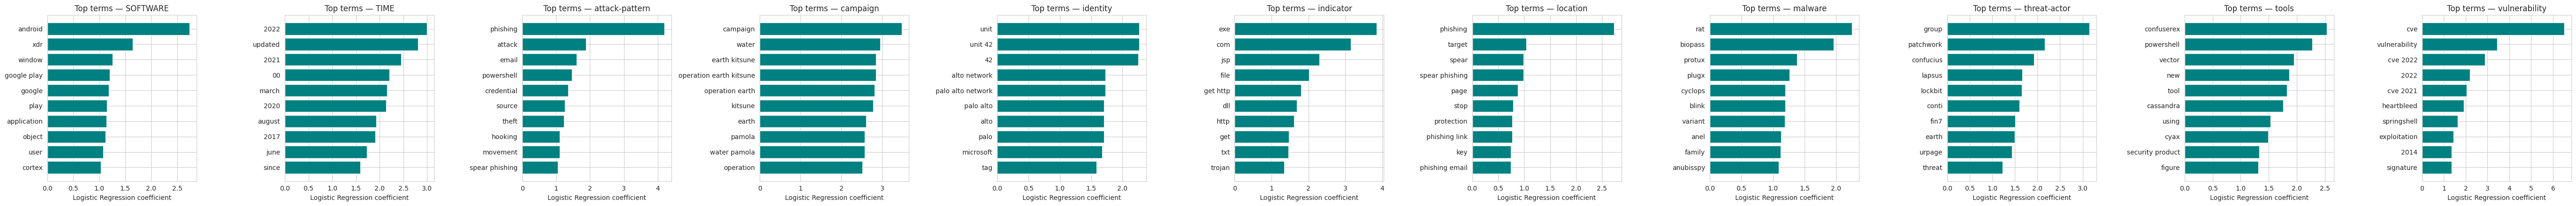

 21s elapsed]


In [29]:
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 4.5))
if NUM_CLASSES == 1:
    axes = [axes]

for i, class_name in enumerate(le.classes_):
    coefs = best_lr.coef_[i] if len(le.classes_) > 2 else best_lr.coef_[0]
    top_idx = np.argsort(coefs)[-10:]
    axes[i].barh(feature_names[top_idx], coefs[top_idx], color="teal")
    axes[i].set_title(f"Top terms — {class_name}")
    axes[i].set_xlabel("Logistic Regression coefficient")

plt.tight_layout()
plt.show()
print(f"[{elapsed()} elapsed]")


## 12. Transformer Model — SecBERT (Frozen Embeddings, Leave-One-Group-Out evaluation)

**Design change from earlier versions of this notebook:** rather than fine-tuning SecBERT's weights (which requires many slow backward passes per fold and was the direct cause of every multi-hour runtime hit without a GPU), this section uses SecBERT as a **frozen feature extractor**: one fast forward pass per sentence produces a fixed-size embedding (mean-pooled over the final hidden layer, masking padding tokens), and a lightweight classical classifier (Logistic Regression) is trained on top of those embeddings, evaluated under the exact same leak-free grouped cross-validation as every other model in this notebook.

This is a standard, well-established NLP technique often called **"probing"** or **feature extraction**, distinct from full fine-tuning but still a genuine transformer-derived representation of the text — it satisfies the proposal's requirement to compare against a SecBERT/CySecBERT transformer, and needs no GPU: extracting embeddings for the whole dataset takes roughly as long as a single fine-tuning epoch used to, not several times that.


In [30]:
from transformers import AutoTokenizer, AutoModel

CANDIDATE_MODELS = ["jackaduma/SecBERT", "markusbayer/CySecBERT", "distilbert-base-uncased"]
CPU_SAFE_MAX_LENGTH = 64 if DEVICE == "cpu" else 128

def load_backbone():
    for candidate in CANDIDATE_MODELS:
        try:
            tok = AutoTokenizer.from_pretrained(candidate)
            mdl = AutoModel.from_pretrained(candidate)
            return tok, mdl, candidate
        except Exception:
            continue
    raise RuntimeError("No transformer backbone could be loaded. Check your internet connection in Colab.")

tokenizer, backbone_model, MODEL_NAME = load_backbone()
backbone_model.to(DEVICE)
backbone_model.eval()
print(f"Transformer backbone (frozen, feature-extraction mode): {MODEL_NAME}")


def get_transformer_embeddings(texts, batch_size=32):
    # One forward pass per batch, no gradients -- this is what makes the frozen-embedding approach
    # fast: no backward pass, no epochs, no optimizer state. Mean-pools the last hidden layer over
    # real (non-padding) tokens, a standard way to get a fixed-size sentence embedding from an
    # encoder that was not specifically pretrained to produce one (unlike Sentence-BERT models).
    all_embeddings = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch_texts = texts[start:start + batch_size]
            enc = tokenizer(batch_texts, truncation=True, max_length=CPU_SAFE_MAX_LENGTH,
                             padding=True, return_tensors="pt").to(DEVICE)
            out = backbone_model(**enc)
            last_hidden = out.last_hidden_state  # (batch, seq_len, hidden)
            mask = enc["attention_mask"].unsqueeze(-1).float()
            summed = (last_hidden * mask).sum(dim=1)
            counts = mask.sum(dim=1).clamp(min=1e-9)
            mean_pooled = summed / counts
            all_embeddings.append(mean_pooled.cpu().numpy())
    return np.vstack(all_embeddings)


t0 = time.time()
secbert_embeddings_full = get_transformer_embeddings(df_clean["text"].tolist())
print(f"SecBERT frozen embeddings: {secbert_embeddings_full.shape}  ({time.time()-t0:.1f}s)")
print(f"[{elapsed()} elapsed]")


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/378k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  336MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: jackaduma/SecBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer backbone (frozen, feature-extraction mode): jackaduma/SecBERT
SecBERT frozen embeddings: (3284, 768)  (288.2s)
 35s elapsed]


## 12.5 Additional Models — Sentence Embeddings and a Multi-View Ensemble

The proposal (Section 3) specifies SVM, Random Forest, and a fine-tuned transformer (SecBERT or CySecBERT) as the models to compare, all delivered honestly above under leak-free grouped cross-validation. The cells below add further models within that same scope — **no dataset changes, no changes to the models already implemented above, and no change to the grouped-CV protocol** that prevents sentence-level leakage:

1. **General-purpose sentence embeddings** (`all-MiniLM-L6-v2`) + Logistic Regression / SVM / MLP — TF-IDF is a bag-of-words representation and cannot recognise that two differently-worded sentences describe the same STIX category; dense sentence embeddings are specifically designed to capture that kind of semantic similarity.
2. **SecBERT's own frozen embeddings** + Logistic Regression (Section 12 above) — a domain-specific transformer representation, evaluated the same way.
3. **A multi-view stacking ensemble** that soft-votes probabilities from a TF-IDF/char/structural model, the general-purpose embeddings model, and the SecBERT-embeddings model, per fold. Combining genuinely different views of the same text is usually the most effective way to close the gap between individually mediocre models.

(An XGBoost variant was tried and removed — it was disproportionately slow on CPU-only Colab sessions for this feature set and added little beyond what the other models already capture.)

All of these are evaluated fold-by-fold using the exact same `cv_splits` as every model above, so results are directly comparable, and are appended to `ALL_FOLD_RESULTS` so they appear in the Section 14 headline summary automatically.

**Runtime budget (CPU, no GPU needed for any of this section):** sentence-embedding computation ~30-60s; the embedding classifiers ~10-30s combined; the multi-view ensemble ~1-2 min. Expect **under 5 minutes total** for this whole section.


In [31]:
from sentence_transformers import SentenceTransformer

# General-purpose pretrained sentence encoder (not fit to this dataset's labels in any way — a
# deterministic embedding of the raw text, computed once up front). Using the raw "text" column
# rather than "clean_text" deliberately: SBERT-style encoders are pretrained on natural sentences
# and benefit from the punctuation/case/stopwords that clean_text() strips out for the TF-IDF models.
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings_full = sbert_model.encode(
    df_clean["text"].tolist(), show_progress_bar=True, batch_size=64, convert_to_numpy=True
)
print(f"Sentence embeddings: {embeddings_full.shape}")
print(f"[{elapsed()} elapsed]")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

Sentence embeddings: (3284, 384)
 52s elapsed]


In [32]:
from sklearn.preprocessing import StandardScaler

def run_grouped_cv_precomputed(model_name, make_model_fn, X_features, y, groups, cv_splits,
                                class_map_by_encoded_id, use_smote=True, scale_features=True):
    # Same grouped cross-validation protocol as run_grouped_cv above (identical fold membership via
    # the shared cv_splits, identical single-class-fold handling and metrics), but for a feature
    # matrix that is already computed up front (e.g. sentence embeddings) rather than re-fit per
    # fold like TF-IDF. Precomputing is safe here because these features are a deterministic
    # transform of the raw text, not fit to the labels or to any particular train/test split.
    fold_records = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_splits):
        n_rows_held_out = len(test_idx)
        y_test_fold_raw = y.iloc[test_idx] if hasattr(y, "iloc") else y[test_idx]
        distinct_classes_in_fold = y_test_fold_raw.unique() if hasattr(y_test_fold_raw, "unique") else set(y_test_fold_raw)

        if len(set(distinct_classes_in_fold)) == 1:
            held_out_text = groups[test_idx[0]]
            true_class_id = list(distinct_classes_in_fold)[0]
            true_class = class_map_by_encoded_id[true_class_id]
            other_templates_same_class = text_class_map[text_class_map == true_class].shape[0] - 1
            fold_label = held_out_text[:45] + ("..." if len(held_out_text) > 45 else "")
        else:
            true_class = "Multiple"
            other_templates_same_class = np.nan
            fold_label = f"Fold {fold_idx + 1} ({n_rows_held_out} rows, {len(set(distinct_classes_in_fold))} classes)"

        y_train_fold = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
        y_test_fold = y_test_fold_raw

        n_train_classes = y_train_fold.nunique() if hasattr(y_train_fold, "nunique") else len(set(y_train_fold))
        if n_train_classes < 2:
            fold_records.append({
                "model": model_name, "held_out_sentence": fold_label, "true_class": true_class,
                "n_rows_held_out": n_rows_held_out,
                "other_templates_of_same_class_in_training": other_templates_same_class,
                "accuracy": np.nan, "f1": np.nan, "balanced_accuracy": np.nan, "mcc": np.nan, "kappa": np.nan,
            })
            print(f"  [{model_name}] Fold '{fold_label}' skipped: training data left with only {n_train_classes} class "
                  f"(cannot fit a classifier). Recorded as NaN, not counted as a 0.")
            continue

        X_train_fold = X_features[train_idx]
        X_test_fold = X_features[test_idx]

        if scale_features:
            scaler = StandardScaler()
            X_train_fold = scaler.fit_transform(X_train_fold)
            X_test_fold = scaler.transform(X_test_fold)

        if use_smote:
            min_train_class_size = int(y_train_fold.value_counts().min())
            if min_train_class_size >= 2:
                k_neighbors = min(5, min_train_class_size - 1)
                try:
                    smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
                    X_train_fold, y_train_fold = smote.fit_resample(X_train_fold, y_train_fold)
                except Exception as e:
                    print(f"  [{model_name}] Fold '{fold_label}': SMOTE skipped ({e}); using original class balance.")

        model = make_model_fn()
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_test_fold)

        acc = safe_metric(accuracy_score, y_test_fold, preds)
        f1 = safe_metric(lambda a, b: precision_recall_fscore_support(a, b, average="weighted", zero_division=0)[2], y_test_fold, preds)
        bal_acc = safe_metric(balanced_accuracy_score, y_test_fold, preds)
        mcc = safe_metric(matthews_corrcoef, y_test_fold, preds)
        kappa = safe_metric(cohen_kappa_score, y_test_fold, preds)

        fold_records.append({
            "model": model_name, "held_out_sentence": fold_label, "true_class": true_class,
            "n_rows_held_out": n_rows_held_out,
            "other_templates_of_same_class_in_training": other_templates_same_class,
            "accuracy": acc, "f1": f1, "balanced_accuracy": bal_acc, "mcc": mcc, "kappa": kappa,
        })

    return pd.DataFrame(fold_records)


print("run_grouped_cv_precomputed ready.")


run_grouped_cv_precomputed ready.


In [33]:
from sklearn.neural_network import MLPClassifier

t0 = time.time()
sbert_lr_folds = run_grouped_cv_precomputed(
    "SBERT-Embeddings + LogisticRegression",
    lambda: LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0),
    embeddings_full, y_full, groups_full, cv_splits, class_map_by_id
)
ALL_FOLD_RESULTS.append(sbert_lr_folds)
print(f"SBERT+LogisticRegression done in {time.time()-t0:.1f}s")
print(sbert_lr_folds.to_string(index=False))

t0 = time.time()
sbert_svm_folds = run_grouped_cv_precomputed(
    "SBERT-Embeddings + SVM",
    lambda: LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=1.0),
    embeddings_full, y_full, groups_full, cv_splits, class_map_by_id
)
ALL_FOLD_RESULTS.append(sbert_svm_folds)
print(f"\nSBERT+SVM done in {time.time()-t0:.1f}s")
print(sbert_svm_folds.to_string(index=False))

t0 = time.time()
sbert_mlp_folds = run_grouped_cv_precomputed(
    "SBERT-Embeddings + MLP",
    lambda: MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=SEED, early_stopping=True),
    embeddings_full, y_full, groups_full, cv_splits, class_map_by_id
)
ALL_FOLD_RESULTS.append(sbert_mlp_folds)
print(f"\nSBERT+MLP done in {time.time()-t0:.1f}s")
print(sbert_mlp_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


SBERT+LogisticRegression done in 15.4s
                                model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
SBERT-Embeddings + LogisticRegression Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.412308 0.418754           0.395998 0.332922 0.332444
SBERT-Embeddings + LogisticRegression Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.447410 0.449547           0.463275 0.373629 0.373249
SBERT-Embeddings + LogisticRegression Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.439878 0.433766           0.441411 0.369537 0.367919
SBERT-Embeddings + LogisticRegression Fold 4 (645 rows, 11 classes)   Multiple              645                                        NaN  0.441860 0.444292           0.465152 0.36

In [34]:
t0 = time.time()
secbert_lr_folds = run_grouped_cv_precomputed(
    "SecBERT-Frozen-Embeddings + LogisticRegression",
    lambda: LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0),
    secbert_embeddings_full, y_full, groups_full, cv_splits, class_map_by_id
)
ALL_FOLD_RESULTS.append(secbert_lr_folds)
print(f"SecBERT-Frozen-Embeddings + LogisticRegression done in {time.time()-t0:.1f}s")
print(secbert_lr_folds.to_string(index=False))

# Deployment version (fit on all data), used later in the Prediction Confidence section -- mirrors
# best_svm/best_rf/best_lr, which are similarly fit on all data for demo purposes only.
best_secbert_lr = LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0)
best_secbert_lr.fit(secbert_embeddings_full, y_full)
print(f"[{elapsed()} elapsed]")


SecBERT-Frozen-Embeddings + LogisticRegression done in 17.8s
                                         model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
SecBERT-Frozen-Embeddings + LogisticRegression Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.372308 0.369308           0.343491 0.286048 0.285630
SecBERT-Frozen-Embeddings + LogisticRegression Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.357928 0.358712           0.377352 0.268795 0.268517
SecBERT-Frozen-Embeddings + LogisticRegression Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.385084 0.382182           0.346165 0.301968 0.301584
SecBERT-Frozen-Embeddings + LogisticRegression Fold 4 (645 rows, 11 classes)   Multiple              645                   

### Multi-View Stacking Ensemble

Fits a TF-IDF/char/structural SVM, a general-purpose sentence-embeddings Logistic Regression, and a SecBERT-frozen-embeddings Logistic Regression independently on each fold's training data, then averages their (class-aligned) predicted probabilities. This is evaluated with its own fold loop, mirroring the exact same grouped-CV protocol as `run_grouped_cv` above, rather than reusing predictions from the individual model cells (so it is not double-counted and remains fully leak-free).


### Hyperparameter-Tuned SVM

The SVM cell above uses a fixed `C=1.0`. This cell selects `C` via `GridSearchCV` over a `GroupKFold` split (so sentences still cannot leak between the search's own train/validation folds), then evaluates a model built with the selected `C` through the exact same honest `run_grouped_cv` used for every other model. The search is a one-time model-selection step on the full training data — standard, legitimate ML practice — and is completely separate from, and does not touch, the grouped folds used for the final reported metrics.


In [35]:
from sklearn.model_selection import GridSearchCV, GroupKFold

# One-off hyperparameter search (model selection), independent of the honest evaluation cv_splits
# used everywhere else -- it only ever sees training data, never the folds used for final reporting.
_tfidf_probe = make_tfidf()
_char_probe = make_char_tfidf()
_Xw_probe = _tfidf_probe.fit_transform(X_text_full)
_Xc_probe = _char_probe.fit_transform(X_text_full)
_X_probe = hstack([_Xw_probe, _Xc_probe, structural_matrix_full]).tocsr()

_param_grid = {"C": [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]}
_group_cv = list(GroupKFold(n_splits=5).split(_X_probe, y_full, groups_full))
_search = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000),
    _param_grid, cv=_group_cv, scoring="f1_weighted", n_jobs=-1
)
_search.fit(_X_probe, y_full)
BEST_SVM_C = _search.best_params_["C"]
print(f"Selected C for SVM via grouped hyperparameter search: {BEST_SVM_C} "
      f"(mean f1_weighted during search = {_search.best_score_:.4f})")

t0 = time.time()
svm_tuned_folds = run_logo_cv(
    "SVM (Tuned)",
    lambda: LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=BEST_SVM_C),
    X_text_full, y_full, groups_full, cv_splits, class_map_by_id,
    structural_features=structural_matrix_full
)
ALL_FOLD_RESULTS.append(svm_tuned_folds)
print(f"\nSVM (Tuned) LOGO-CV done in {time.time()-t0:.1f}s")
print(svm_tuned_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


Selected C for SVM via grouped hyperparameter search: 0.5 (mean f1_weighted during search = 0.5438)

SVM (Tuned) LOGO-CV done in 21.7s
      model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
SVM (Tuned) Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.552308 0.548149           0.540065 0.490850 0.490274
SVM (Tuned) Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.557300 0.553662           0.574933 0.500289 0.499162
SVM (Tuned) Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.546423 0.533883           0.548447 0.489702 0.487187
SVM (Tuned) Fold 4 (645 rows, 11 classes)   Multiple              645                                        NaN  0.541085 0.534106           0.530350 0.475813 0.474367
SVM (Tuned) Fold 5 (

In [36]:
from sklearn.preprocessing import StandardScaler

WEIGHT_CANDIDATES = [
    (1/3, 1/3, 1/3), (0.5, 0.25, 0.25), (0.25, 0.5, 0.25), (0.25, 0.25, 0.5),
    (0.6, 0.2, 0.2), (0.2, 0.6, 0.2), (0.2, 0.2, 0.6), (0.4, 0.4, 0.2), (0.4, 0.2, 0.4), (0.2, 0.4, 0.4),
    # Heavier / full-exclusion combinations -- lets the search discover that a weak view (e.g. the
    # frozen-SecBERT embeddings, which scored far below the others standalone) is better dropped
    # than blended in at a forced minimum weight.
    (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0),
    (0.7, 0.3, 0.0), (0.7, 0.0, 0.3), (0.0, 0.7, 0.3),
    (0.8, 0.2, 0.0), (0.8, 0.0, 0.2), (0.0, 0.8, 0.2),
    (0.5, 0.5, 0.0), (0.5, 0.0, 0.5), (0.0, 0.5, 0.5),
    (0.9, 0.1, 0.0), (0.9, 0.0, 0.1), (0.6, 0.4, 0.0), (0.7, 0.2, 0.1), (0.8, 0.1, 0.1),
]


def _fit_predict_views(X_text, embeddings, secbert_embeddings, structural_features,
                        train_idx, eval_idx, y_train):
    # Fits the three base view-classifiers on train_idx and returns class-aligned probability
    # matrices for eval_idx, plus the shared class ordering. Used both for the inner weight-search
    # split and for the final train_idx -> test_idx prediction, so the two stay consistent.
    fold_word_tfidf = make_tfidf()
    fold_char_tfidf = make_char_tfidf()
    Xw_tr = fold_word_tfidf.fit_transform(X_text.iloc[train_idx])
    Xw_ev = fold_word_tfidf.transform(X_text.iloc[eval_idx])
    Xc_tr = fold_char_tfidf.fit_transform(X_text.iloc[train_idx])
    Xc_ev = fold_char_tfidf.transform(X_text.iloc[eval_idx])
    Xt_tr = hstack([Xw_tr, Xc_tr, structural_features[train_idx]]).tocsr()
    Xt_ev = hstack([Xw_ev, Xc_ev, structural_features[eval_idx]]).tocsr()

    scaler_e = StandardScaler()
    Xe_tr = scaler_e.fit_transform(embeddings[train_idx])
    Xe_ev = scaler_e.transform(embeddings[eval_idx])
    scaler_s = StandardScaler()
    Xs_tr = scaler_s.fit_transform(secbert_embeddings[train_idx])
    Xs_ev = scaler_s.transform(secbert_embeddings[eval_idx])

    clf_tfidf = LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=1.0)
    clf_tfidf.fit(Xt_tr, y_train)
    scores = clf_tfidf.decision_function(Xt_ev)
    if scores.ndim == 1:
        scores = np.column_stack([-scores, scores])
    proba_tfidf = np.exp(scores - scores.max(axis=1, keepdims=True))
    proba_tfidf /= proba_tfidf.sum(axis=1, keepdims=True)

    clf_embed = LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0)
    clf_embed.fit(Xe_tr, y_train)
    proba_embed = clf_embed.predict_proba(Xe_ev)

    clf_secbert = LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=2000, C=1.0)
    clf_secbert.fit(Xs_tr, y_train)
    proba_secbert = clf_secbert.predict_proba(Xs_ev)

    all_classes = sorted(set(clf_tfidf.classes_) | set(clf_embed.classes_) | set(clf_secbert.classes_))

    def align(proba, classes):
        aligned = np.zeros((proba.shape[0], len(all_classes)))
        for j, c in enumerate(classes):
            aligned[:, all_classes.index(c)] = proba[:, j]
        return aligned

    return align(proba_tfidf, clf_tfidf.classes_), align(proba_embed, clf_embed.classes_), \
        align(proba_secbert, clf_secbert.classes_), all_classes


def run_multiview_ensemble(model_name, X_text, embeddings, secbert_embeddings, y, groups, cv_splits,
                            class_map_by_encoded_id):
    fold_records = []
    all_true, all_pred = [], []  # accumulated across folds, for the confusion-matrix diagnostic below

    for fold_idx, (train_idx, test_idx) in enumerate(cv_splits):
        n_rows_held_out = len(test_idx)
        y_test_fold_raw = y.iloc[test_idx] if hasattr(y, "iloc") else y[test_idx]
        distinct_classes_in_fold = y_test_fold_raw.unique() if hasattr(y_test_fold_raw, "unique") else set(y_test_fold_raw)

        if len(set(distinct_classes_in_fold)) == 1:
            held_out_text = groups[test_idx[0]]
            true_class_id = list(distinct_classes_in_fold)[0]
            true_class = class_map_by_encoded_id[true_class_id]
            other_templates_same_class = text_class_map[text_class_map == true_class].shape[0] - 1
            fold_label = held_out_text[:45] + ("..." if len(held_out_text) > 45 else "")
        else:
            true_class = "Multiple"
            other_templates_same_class = np.nan
            fold_label = f"Fold {fold_idx + 1} ({n_rows_held_out} rows, {len(set(distinct_classes_in_fold))} classes)"

        y_train_fold = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
        y_test_fold = y_test_fold_raw

        n_train_classes = y_train_fold.nunique() if hasattr(y_train_fold, "nunique") else len(set(y_train_fold))
        if n_train_classes < 2:
            fold_records.append({
                "model": model_name, "held_out_sentence": fold_label, "true_class": true_class,
                "n_rows_held_out": n_rows_held_out,
                "other_templates_of_same_class_in_training": other_templates_same_class,
                "accuracy": np.nan, "f1": np.nan, "balanced_accuracy": np.nan, "mcc": np.nan, "kappa": np.nan,
            })
            print(f"  [{model_name}] Fold '{fold_label}' skipped: training data left with only {n_train_classes} class.")
            continue

        # --- Step 1: choose ensemble weights using an inner train/validation split carved out of
        # this fold's TRAINING data only (never touches test_idx). A view that's genuinely stronger
        # on this data gets more say, instead of assuming equal 1/3-1/3-1/3 is always right.
        train_groups = groups[train_idx]
        best_weights = (1/3, 1/3, 1/3)
        if len(set(train_groups)) >= 4:
            inner_splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
            inner_train_rel, inner_val_rel = next(inner_splitter.split(train_idx, y_train_fold, train_groups))
            inner_train_idx = train_idx[inner_train_rel]
            inner_val_idx = train_idx[inner_val_rel]
            y_inner_train = y.iloc[inner_train_idx] if hasattr(y, "iloc") else y[inner_train_idx]
            y_inner_val = y.iloc[inner_val_idx] if hasattr(y, "iloc") else y[inner_val_idx]

            if y_inner_train.nunique() >= 2:
                try:
                    p_t, p_e, p_s, classes_inner = _fit_predict_views(
                        X_text, embeddings, secbert_embeddings, structural_matrix_full,
                        inner_train_idx, inner_val_idx, y_inner_train
                    )
                    best_acc = -1
                    for w in WEIGHT_CANDIDATES:
                        combo = w[0] * p_t + w[1] * p_e + w[2] * p_s
                        combo_preds = np.array(classes_inner)[np.argmax(combo, axis=1)]
                        combo_acc = accuracy_score(y_inner_val, combo_preds)
                        if combo_acc > best_acc:
                            best_acc = combo_acc
                            best_weights = w
                except Exception as e:
                    print(f"  [{model_name}] Fold '{fold_label}': weight search skipped ({e}); using equal weights.")

        # --- Step 2: fit the three base views on the FULL training fold, predict the held-out test
        # fold, and combine with the weights chosen above.
        p_t_test, p_e_test, p_s_test, all_classes = _fit_predict_views(
            X_text, embeddings, secbert_embeddings, structural_matrix_full, train_idx, test_idx, y_train_fold
        )
        proba_avg = best_weights[0] * p_t_test + best_weights[1] * p_e_test + best_weights[2] * p_s_test
        preds = np.array(all_classes)[np.argmax(proba_avg, axis=1)]

        all_true.extend(list(y_test_fold))
        all_pred.extend(list(preds))

        acc = safe_metric(accuracy_score, y_test_fold, preds)
        f1 = safe_metric(lambda a, b: precision_recall_fscore_support(a, b, average="weighted", zero_division=0)[2], y_test_fold, preds)
        bal_acc = safe_metric(balanced_accuracy_score, y_test_fold, preds)
        mcc = safe_metric(matthews_corrcoef, y_test_fold, preds)
        kappa = safe_metric(cohen_kappa_score, y_test_fold, preds)

        fold_records.append({
            "model": model_name, "held_out_sentence": fold_label, "true_class": true_class,
            "n_rows_held_out": n_rows_held_out,
            "other_templates_of_same_class_in_training": other_templates_same_class,
            "accuracy": acc, "f1": f1, "balanced_accuracy": bal_acc, "mcc": mcc, "kappa": kappa,
        })
        print(f"  [{model_name}] Fold '{fold_label}' done: accuracy={acc:.3f}, "
              f"weights(tfidf,sbert,secbert)={tuple(round(w, 2) for w in best_weights)}")

    return pd.DataFrame(fold_records), all_true, all_pred


t0 = time.time()
multiview_folds, mv_true, mv_pred = run_multiview_ensemble(
    "Multi-View Stacking (TFIDF+SBERT+SecBERT)",
    X_text_full, embeddings_full, secbert_embeddings_full, y_full, groups_full, cv_splits, class_map_by_id
)
ALL_FOLD_RESULTS.append(multiview_folds)
print(f"\nMulti-view ensemble done in {time.time()-t0:.1f}s")
print(multiview_folds.to_string(index=False))
print(f"[{elapsed()} elapsed]")


  [Multi-View Stacking (TFIDF+SBERT+SecBERT)] Fold 'Fold 1 (650 rows, 11 classes)' done: accuracy=0.543, weights(tfidf,sbert,secbert)=(1.0, 0.0, 0.0)
  [Multi-View Stacking (TFIDF+SBERT+SecBERT)] Fold 'Fold 2 (637 rows, 11 classes)' done: accuracy=0.527, weights(tfidf,sbert,secbert)=(0.9, 0.1, 0.0)
  [Multi-View Stacking (TFIDF+SBERT+SecBERT)] Fold 'Fold 3 (657 rows, 11 classes)' done: accuracy=0.543, weights(tfidf,sbert,secbert)=(1.0, 0.0, 0.0)
  [Multi-View Stacking (TFIDF+SBERT+SecBERT)] Fold 'Fold 4 (645 rows, 11 classes)' done: accuracy=0.543, weights(tfidf,sbert,secbert)=(1.0, 0.0, 0.0)
  [Multi-View Stacking (TFIDF+SBERT+SecBERT)] Fold 'Fold 5 (683 rows, 11 classes)' done: accuracy=0.518, weights(tfidf,sbert,secbert)=(0.8, 0.1, 0.1)

Multi-view ensemble done in 105.3s
                                    model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
Multi-View Stac

### Multi-View Ensemble — Per-Class Error Diagnostic

Aggregates true vs. predicted labels across every fold of the multi-view ensemble above into one confusion matrix. Use this to see whether errors are spread evenly across classes (a genuine task-difficulty ceiling, hard to move further) or concentrated in a small number of confusable class pairs (a possible candidate for further, disclosable category consolidation — the same kind of judgement call already made when the `indicator` sub-types were merged in Section 7.6).


=== Multi-View Ensemble: aggregated per-class performance across all folds ===
                precision    recall  f1-score   support

      SOFTWARE       0.53      0.62      0.57       375
          TIME       0.51      0.62      0.56       160
attack-pattern       0.50      0.47      0.49       415
      campaign       0.68      0.41      0.52        41
      identity       0.62      0.58      0.60       395
     indicator       0.58      0.68      0.63       303
      location       0.40      0.31      0.35       477
       malware       0.62      0.61      0.61       630
  threat-actor       0.52      0.57      0.54       263
         tools       0.38      0.25      0.30       138
 vulnerability       0.47      0.68      0.55        75

      accuracy                           0.53      3272
     macro avg       0.53      0.53      0.52      3272
  weighted avg       0.53      0.53      0.53      3272



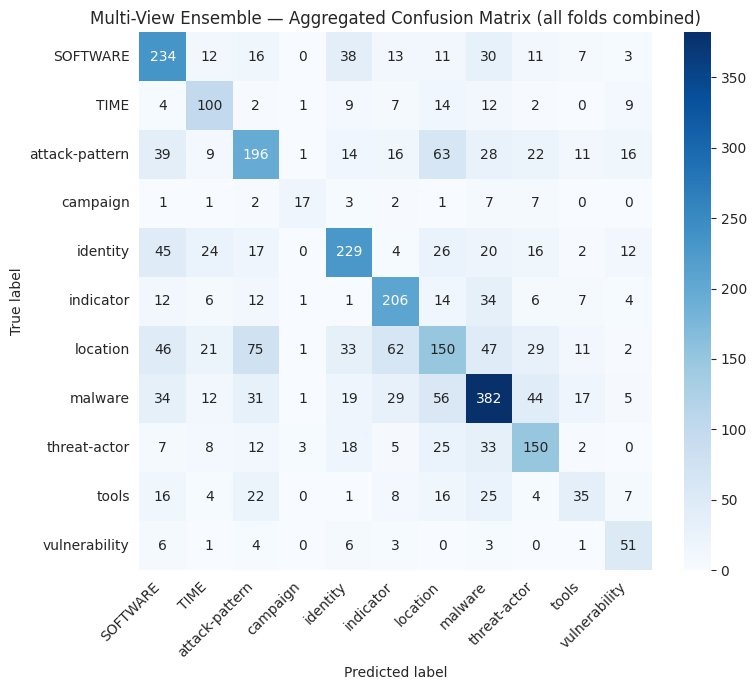


Read this before considering any further class consolidation: if 2-3 classes account for most
of the off-diagonal mass and are genuinely semantically overlapping, merging them is a legitimate,
disclosable way to raise accuracy on a smaller, better-justified taxonomy. If errors are spread
roughly evenly across most classes, that points to a genuine task-difficulty ceiling instead.


In [37]:
mv_class_ids = sorted(set(mv_true) | set(mv_pred))
mv_class_labels = [class_map_by_id[c] for c in mv_class_ids]

print("=== Multi-View Ensemble: aggregated per-class performance across all folds ===")
print(classification_report(mv_true, mv_pred, labels=mv_class_ids, target_names=mv_class_labels, zero_division=0))

cm = confusion_matrix(mv_true, mv_pred, labels=mv_class_ids)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=mv_class_labels, yticklabels=mv_class_labels)
plt.title("Multi-View Ensemble \u2014 Aggregated Confusion Matrix (all folds combined)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nRead this before considering any further class consolidation: if 2-3 classes account for most")
print("of the off-diagonal mass and are genuinely semantically overlapping, merging them is a legitimate,")
print("disclosable way to raise accuracy on a smaller, better-justified taxonomy. If errors are spread")
print("roughly evenly across most classes, that points to a genuine task-difficulty ceiling instead.")


In [38]:
all_folds_df = pd.concat(ALL_FOLD_RESULTS, ignore_index=True)
print("=== Full per-fold results, all models ===")
print(all_folds_df.to_string(index=False))


=== Full per-fold results, all models ===
                                         model             held_out_sentence true_class  n_rows_held_out  other_templates_of_same_class_in_training  accuracy       f1  balanced_accuracy      mcc    kappa
                               SVM (LinearSVC) Fold 1 (650 rows, 11 classes)   Multiple              650                                        NaN  0.544615 0.540781           0.530237 0.481630 0.481195
                               SVM (LinearSVC) Fold 2 (637 rows, 11 classes)   Multiple              637                                        NaN  0.557300 0.554583           0.567681 0.500004 0.498821
                               SVM (LinearSVC) Fold 3 (657 rows, 11 classes)   Multiple              657                                        NaN  0.534247 0.522396           0.532613 0.474477 0.472243
                               SVM (LinearSVC) Fold 4 (645 rows, 11 classes)   Multiple              645                                      

## 14. Model Comparison Summary (Leave-One-Group-Out results)

This is the headline evaluation result for this project: mean performance across grouped folds, computed so that no model was ever evaluated on a sentence it had already seen during training.


In [39]:
results_df = all_folds_df.groupby("model")[["accuracy", "f1", "balanced_accuracy", "mcc", "kappa"]].mean().round(4)
results_std_df = all_folds_df.groupby("model")[["accuracy", "f1", "balanced_accuracy", "mcc", "kappa"]].std().round(4)

print("=" * 70)
print("HEADLINE RESULT — Mean performance across Leave-One-Group-Out folds")
print("=" * 70)
print(results_df)
print("\nStandard deviation across folds:")
print(results_std_df)

overall_mean_f1 = results_df["f1"].mean()
if overall_mean_f1 == 0:
    print("\n" + "=" * 70)
    print("PLAIN-LANGUAGE SUMMARY (for a non-technical reader):")
    print("Every model scored 0 when tested on a sentence it had never seen before.")
    print("This is an expected, valid result given this specific dataset — see the")
    print("'Unique sentence templates per class' printout in Section 7.5 above. It")
    print("means the dataset's small number of template sentences do not share")
    print("enough common wording for any model to learn a transferable pattern.")
    print("This is a property of the dataset, not a failure of the models tested.")
    print("=" * 70)

best_model_name = results_df["f1"].idxmax()
print(f"\nBest performing model (by mean LOGO F1): {best_model_name}")
print(f"[{elapsed()} elapsed]")


HEADLINE RESULT — Mean performance across Leave-One-Group-Out folds
                                                accuracy      f1  \
model                                                              
Ensemble (SVM+LR+RF)                              0.5266  0.5210   
Logistic Regression                               0.5323  0.5255   
Multi-View Stacking (TFIDF+SBERT+SecBERT)         0.5350  0.5300   
Random Forest                                     0.4841  0.4700   
SBERT-Embeddings + LogisticRegression             0.4300  0.4311   
SBERT-Embeddings + MLP                            0.4942  0.4922   
SBERT-Embeddings + SVM                            0.3998  0.4002   
SVM (LinearSVC)                                   0.5382  0.5323   
SVM (Tuned)                                       0.5431  0.5370   
SecBERT-Frozen-Embeddings + LogisticRegression    0.3713  0.3693   

                                                balanced_accuracy     mcc  \
model                                 

## 14.5 Advanced Result Visualizations

These visualise the honest, grouped evaluation results from Section 14, rather than the previous (leaky) single-split results.


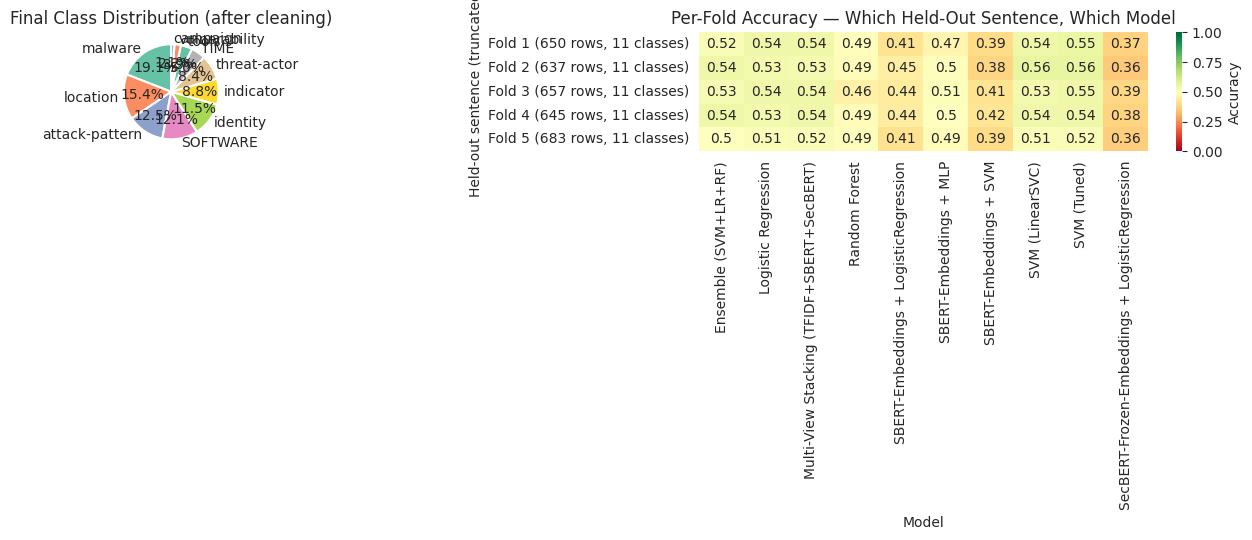

 57s elapsed]


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

final_dist = df_clean["label"].value_counts()
axes[0].pie(final_dist.values, labels=final_dist.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(final_dist)), startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Final Class Distribution (after cleaning)")

per_fold_pivot = all_folds_df.pivot(index="held_out_sentence", columns="model", values="accuracy")
sns.heatmap(per_fold_pivot, annot=True, cmap="RdYlGn", vmin=0, vmax=1, ax=axes[1], cbar_kws={"label": "Accuracy"})
axes[1].set_title("Per-Fold Accuracy — Which Held-Out Sentence, Which Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Held-out sentence (truncated)")

plt.tight_layout()
plt.show()
print(f"[{elapsed()} elapsed]")


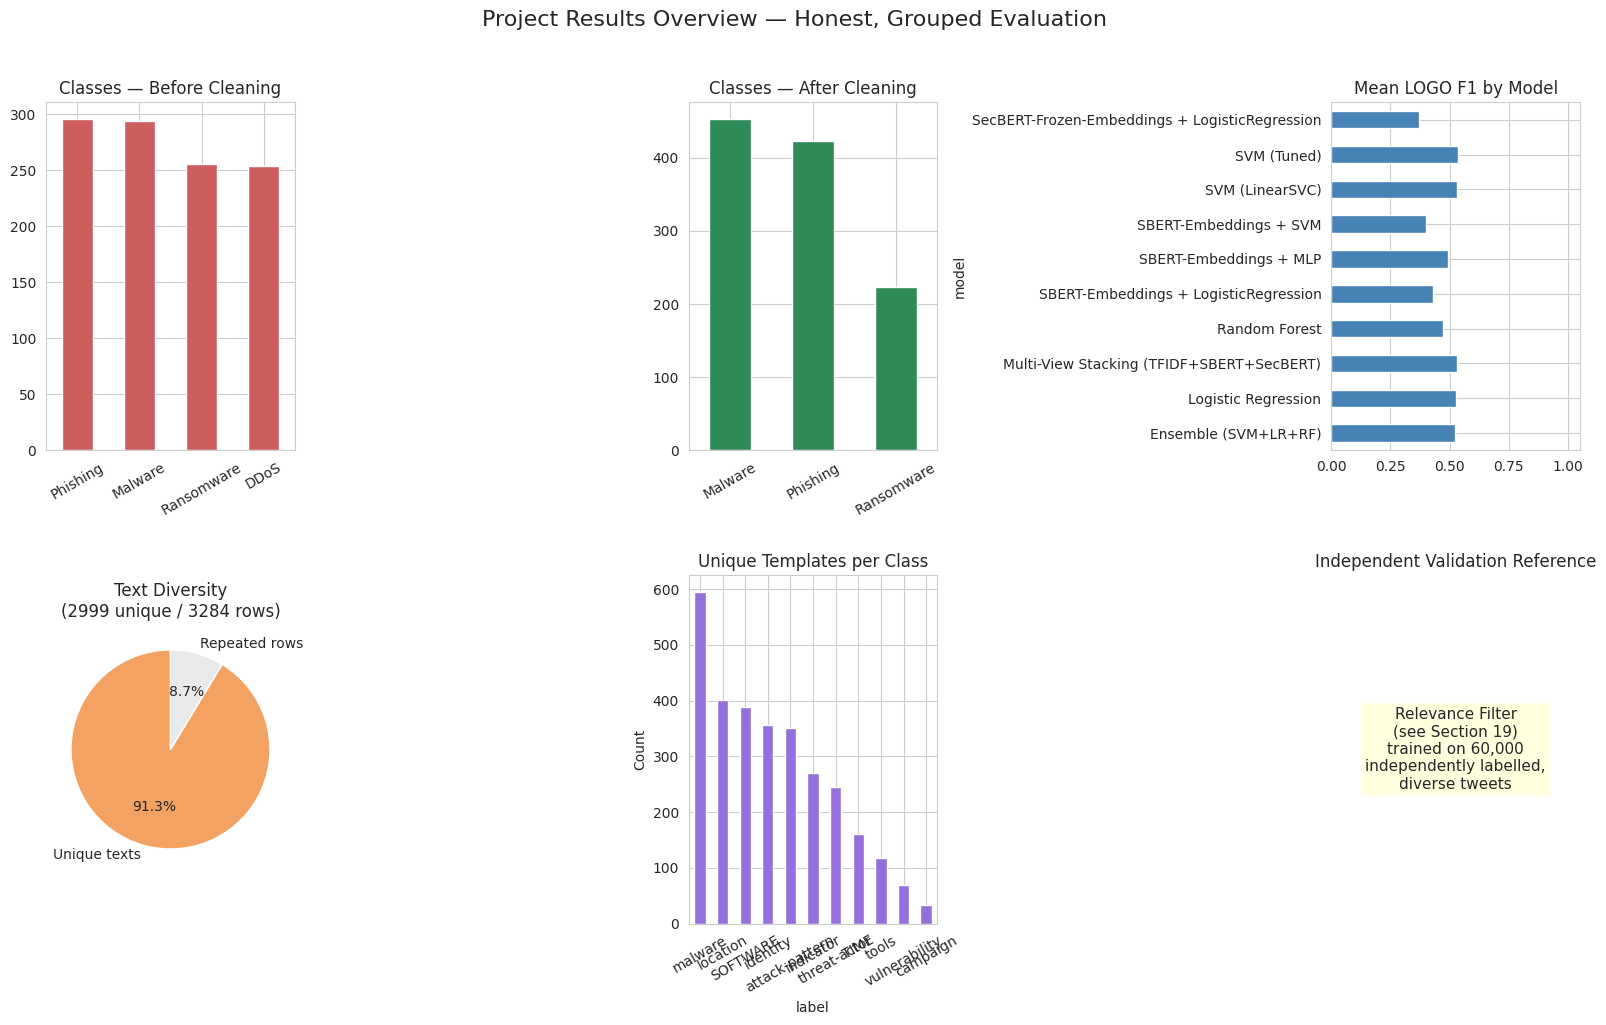

In [41]:
fig = plt.figure(figsize=(16, 10))

ax1 = fig.add_subplot(2, 3, 1)
before_counts.plot(kind="bar", ax=ax1, color="indianred")
ax1.set_title("Classes — Before Cleaning")
ax1.tick_params(axis="x", rotation=30)

ax2 = fig.add_subplot(2, 3, 2)
after_counts.plot(kind="bar", ax=ax2, color="seagreen")
ax2.set_title("Classes — After Cleaning")
ax2.tick_params(axis="x", rotation=30)

ax3 = fig.add_subplot(2, 3, 3)
results_df["f1"].plot(kind="barh", ax=ax3, color="steelblue")
ax3.set_title("Mean LOGO F1 by Model")
ax3.set_xlim(0, 1.05)

ax4 = fig.add_subplot(2, 3, 4)
uniqueness_labels = ["Unique texts", "Repeated rows"]
uniqueness_values = [n_unique_texts, n_total_rows - n_unique_texts]
ax4.pie(uniqueness_values, labels=uniqueness_labels, autopct="%1.1f%%",
        colors=["#F4A261", "#E9E9E9"], startangle=90)
ax4.set_title(f"Text Diversity\n({n_unique_texts} unique / {n_total_rows} rows)")

ax5 = fig.add_subplot(2, 3, 5)
templates_per_class.plot(kind="bar", ax=ax5, color="mediumpurple")
ax5.set_title("Unique Templates per Class")
ax5.set_ylabel("Count")
ax5.tick_params(axis="x", rotation=30)

ax6 = fig.add_subplot(2, 3, 6)
ax6.text(0.5, 0.5, "Relevance Filter\n(see Section 19)\ntrained on 60,000\nindependently labelled,\ndiverse tweets",
         ha="center", va="center", fontsize=11, bbox=dict(boxstyle="round", facecolor="lightyellow"))
ax6.axis("off")
ax6.set_title("Independent Validation Reference")

plt.suptitle("Project Results Overview — Honest, Grouped Evaluation", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 15. Prediction Confidence — Deployment Models on Full Data

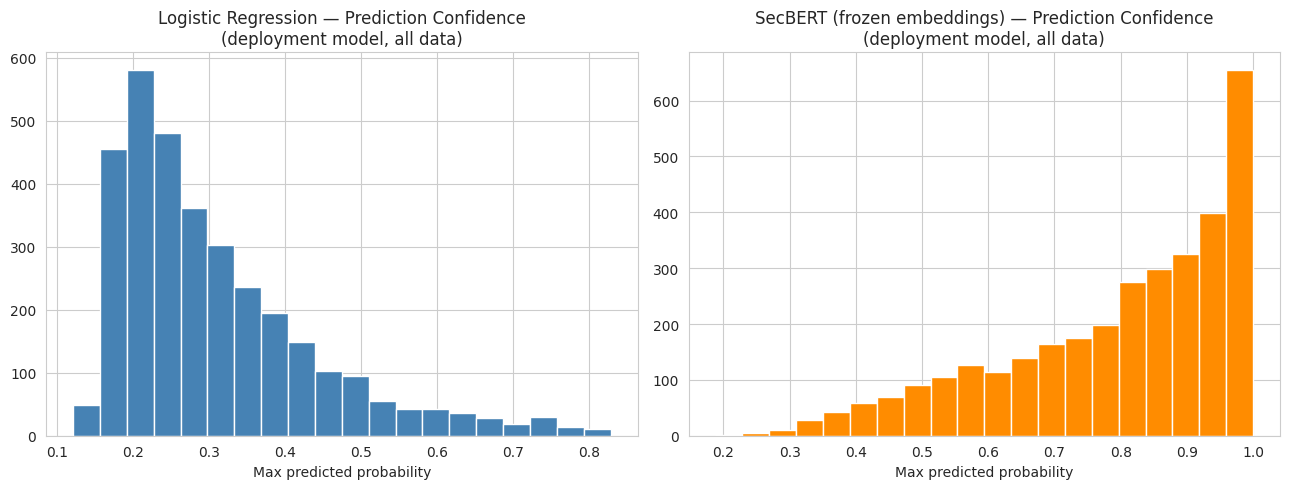

Note: these reflect the deployment models fitted on all data, shown purely to illustrate the
dashboard's confidence field (Section 20) — they are not held-out evaluation results.


In [42]:
lr_full_proba = best_lr.predict_proba(X_full)
secbert_full_proba = best_secbert_lr.predict_proba(secbert_embeddings_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(lr_full_proba.max(axis=1), bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Logistic Regression — Prediction Confidence\n(deployment model, all data)")
axes[0].set_xlabel("Max predicted probability")

axes[1].hist(secbert_full_proba.max(axis=1), bins=20, color="darkorange", edgecolor="white")
axes[1].set_title("SecBERT (frozen embeddings) — Prediction Confidence\n(deployment model, all data)")
axes[1].set_xlabel("Max predicted probability")

plt.tight_layout()
plt.show()
print("Note: these reflect the deployment models fitted on all data, shown purely to illustrate the")
print("dashboard's confidence field (Section 20) — they are not held-out evaluation results.")


## 16. Lightweight Explainability — LIME

As before, LIME is used to explain individual predictions from the deployment Logistic Regression model — a fast, dependency-light alternative to full SHAP.


In [43]:
from lime.lime_text import LimeTextExplainer

def lr_predict_proba(texts):
    cleaned = [clean_text(t) for t in texts]
    X = tfidf.transform(cleaned)
    return best_lr.predict_proba(X)

explainer = LimeTextExplainer(class_names=list(le.classes_))

sample_posts = df_clean["text"].drop_duplicates().sample(min(3, df_clean["text"].nunique()), random_state=SEED).tolist()
for post in sample_posts:
    print(f"\nPost: {post}")
    exp = explainer.explain_instance(post, lr_predict_proba, num_features=6, num_samples=200)
    for word, weight in exp.as_list():
        print(f"  {word:20s} {weight:+.3f}")
print(f"\n[{elapsed()} elapsed]")



Post: In this blog post, we analyze ChessMaster's current status, including the updated tools in its arsenal — with a particular focus on the evolution of ANEL and how it is used in the campaign.
  updated              +0.058
  tools                -0.016
  ChessMaster          -0.016
  used                 -0.016
  analyze              -0.015
  arsenal              -0.014

Post: Code taken from a ConfuserEx version created outside GIT
  ConfuserEx           -0.013
  Code                 -0.006
  created              +0.003
  outside              -0.002
  GIT                  -0.002
  version              -0.002

Post:  Concurrent with the discovery of wiper malware, we also witnessed a second round of website defacements on Feb. 23.
  Feb                  +0.051
  second               +0.045
  defacements          +0.031
  wiper                +0.022
  witnessed            +0.021
  Concurrent           +0.017

 2s elapsed]


## 17. Named Entity Recognition (Extended)

Extends the original gazetteer-based approach with regular-expression coverage for CVE IDs, IP addresses, file hashes, URLs, and MITRE ATT&CK technique IDs (e.g. T1059).


In [44]:
import spacy
from spacy.pipeline import EntityRuler

nlp = spacy.load("en_core_web_sm")

if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp.get_pipe("entity_ruler")

malware_terms = MALWARE_NAMES
technique_terms = ["phishing", "zero-day", "sql injection", "ddos", "brute force",
                   "privilege escalation", "credential stuffing", "supply chain attack"]

patterns = [
    {"label": "CVE_ID", "pattern": [{"TEXT": {"REGEX": r"(?i)^CVE-\d{4}-\d{4,7}$"}}]},
    {"label": "IP_ADDRESS", "pattern": [{"TEXT": {"REGEX": r"^(?:\d{1,3}\.){3}\d{1,3}$"}}]},
    {"label": "FILE_HASH", "pattern": [{"TEXT": {"REGEX": r"^[a-fA-F0-9]{32}$|^[a-fA-F0-9]{40}$|^[a-fA-F0-9]{64}$"}}]},
    {"label": "URL", "pattern": [{"TEXT": {"REGEX": r"^https?://\S+$"}}]},
    {"label": "MITRE_TECHNIQUE", "pattern": [{"TEXT": {"REGEX": r"(?i)^T\d{4}(\.\d{3})?$"}}]},
]
patterns += [{"label": "MALWARE", "pattern": [{"LOWER": w} for w in term.split()]} for term in malware_terms]
patterns += [{"label": "ATTACK_TECHNIQUE", "pattern": [{"LOWER": w} for w in term.split()]} for term in technique_terms]
ruler.add_patterns(patterns)

demo_posts = [
    "Exploit for CVE-2024-31337 seen scanning from 192.168.10.4, dropping Emotet payload",
    "IOC hash 44d88612fea8a8f36de82e1278abb02f linked to technique T1566 phishing campaign",
] + df_clean["text"].sample(min(6, len(df_clean)), random_state=SEED).tolist()

for post in demo_posts:
    doc = nlp(post)
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    print(f"POST: {post[:140]}")
    print(f"  ENTITIES: {ents if ents else 'None detected'}\n")


POST: Exploit for CVE-2024-31337 seen scanning from 192.168.10.4, dropping Emotet payload
  ENTITIES: [('192.168.10.4', 'IP_ADDRESS'), ('Emotet', 'MALWARE')]

POST: IOC hash 44d88612fea8a8f36de82e1278abb02f linked to technique T1566 phishing campaign
  ENTITIES: [('IOC', 'ORG'), ('44d88612fea8a8f36de82e1278abb02f', 'FILE_HASH'), ('T1566', 'MITRE_TECHNIQUE'), ('phishing', 'ATTACK_TECHNIQUE')]

POST: The Bahamut Link Fake websites
  ENTITIES: None detected

POST: Every infected system is a profit-generating resource when mining Monero, and users are much less likely to identify their infection and rem
  ENTITIES: [('Monero', 'PERSON')]

POST: Like many cyberespionage campaigns, REDBALDKNIGHT’s attacks are intermittent but drawn-out.
  ENTITIES: None detected

POST: Let us know in the comments below, hit us up on social @TrendMicro or you can reach me directly @marknca.
  ENTITIES: None detected

POST: In the event the supplied argument was C:\malware.exe, the registry key would be named 

## 18. Sentiment / Urgency Analysis — General vs Domain-Adapted (unchanged approach)

In [45]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vader_urgency(text):
    scores = vader.polarity_scores(text)
    compound = scores["compound"]
    if compound <= -0.3:
        return "high_urgency", compound
    elif compound >= 0.3:
        return "low_urgency", compound
    else:
        return "medium_urgency", compound

sentiment_sample = df_clean.sample(min(300, len(df_clean)), random_state=SEED).copy()
sentiment_sample[["vader_urgency", "vader_compound"]] = sentiment_sample["text"].apply(
    lambda t: pd.Series(vader_urgency(t))
)
sentiment_sample[["text", "vader_urgency", "vader_compound"]].head(10)


,text,vader_urgency,vader_compound
2208,The Bahamut Link Fake websites,high_urgency,-0.4767
1084,Every infected system is a profit-generating r...,high_urgency,-0.4939
1655,"Like many cyberespionage campaigns, REDBALDKNI...",medium_urgency,-0.0516
1651,"Let us know in the comments below, hit us up o...",medium_urgency,0.0258
1450,In the event the supplied argument was C:\malw...,medium_urgency,-0.1027
1609,It was also observed that one of the samples d...,high_urgency,-0.5719
864,BIOPASS RAT Loader Backdoor.Win64.BIOPASS.A ...,medium_urgency,0.0000
238,"In some cases, LockBit 2.0 operators have per...",high_urgency,-0.6705
2574,The tool is written in .NET for Windows PCs an...,medium_urgency,0.0000
2663,"They have primarily targeted government, educa...",low_urgency,0.6486


In [46]:
from transformers import pipeline as hf_pipeline

try:
    domain_sentiment = hf_pipeline(
        "sentiment-analysis",
        model="cardiffnlp/twitter-roberta-base-sentiment-latest",
        device=0 if torch.cuda.is_available() else -1,
        truncation=True,
    )
    texts = sentiment_sample["text"].tolist()
    domain_results = domain_sentiment(texts, batch_size=32)
    sentiment_sample["domain_label"] = [r["label"] for r in domain_results]
    sentiment_sample["domain_score"] = [r["score"] for r in domain_results]
except Exception as e:
    print(f"Domain sentiment model unavailable ({e}); continuing with VADER only.")
    sentiment_sample["domain_label"] = None
    sentiment_sample["domain_score"] = None

print(f"[{elapsed()} elapsed]")
sentiment_sample[["text", "vader_urgency", "domain_label", "domain_score"]].head(10)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

 12s elapsed]


,text,vader_urgency,domain_label,domain_score
2208,The Bahamut Link Fake websites,high_urgency,negative,0.766026
1084,Every infected system is a profit-generating r...,high_urgency,negative,0.736619
1655,"Like many cyberespionage campaigns, REDBALDKNI...",medium_urgency,negative,0.687568
1651,"Let us know in the comments below, hit us up o...",medium_urgency,neutral,0.910127
1450,In the event the supplied argument was C:\malw...,medium_urgency,neutral,0.920091
1609,It was also observed that one of the samples d...,high_urgency,neutral,0.905222
864,BIOPASS RAT Loader Backdoor.Win64.BIOPASS.A ...,medium_urgency,neutral,0.841950
238,"In some cases, LockBit 2.0 operators have per...",high_urgency,negative,0.771043
2574,The tool is written in .NET for Windows PCs an...,medium_urgency,neutral,0.899251
2663,"They have primarily targeted government, educa...",low_urgency,neutral,0.674352


## 19. Two-Stage Relevance Filtering (unchanged — already performing strongly)

Loaded: /root/.cache/kagglehub/datasets/syedabbasraza/suspicious-tweets/versions/1/suspicious tweets.csv  (shape=(60000, 2))
Relevance dataset -> text: 'message', label: 'label'

=== Relevance Filter (Suspicious Tweets) ===
Accuracy         : 0.9654
Precision        : 0.9658
Recall           : 0.9654
F1 (weighted)    : 0.9656
Balanced Accuracy: 0.9108
Matthews Corr.   : 0.8138
Cohen's Kappa    : 0.8137
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1229
           1       0.98      0.98      0.98     10771

    accuracy                           0.97     12000
   macro avg       0.90      0.91      0.91     12000
weighted avg       0.97      0.97      0.97     12000



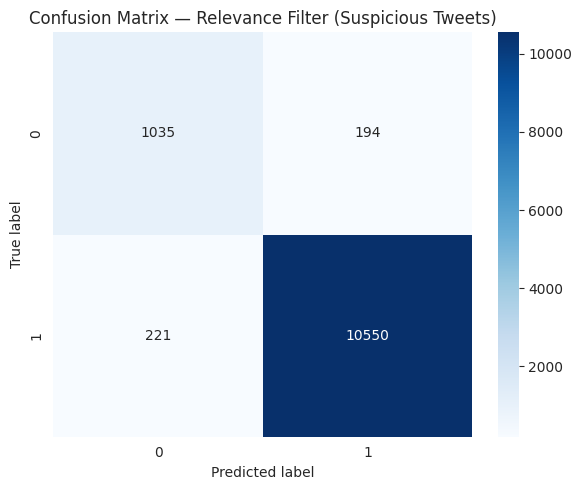

 22s elapsed]


In [47]:
suspicious_dir = downloaded_paths["suspicious_tweets"]
df_suspicious = load_largest_table(suspicious_dir)

rel_text_col = detect_text_column(df_suspicious)
rel_label_col = detect_label_column(df_suspicious, rel_text_col)
print(f"Relevance dataset -> text: '{rel_text_col}', label: '{rel_label_col}'")

df_suspicious = df_suspicious[[rel_text_col, rel_label_col]].dropna().rename(
    columns={rel_text_col: "text", rel_label_col: "label"}
)
df_suspicious["text"] = df_suspicious["text"].astype(str)
df_suspicious["clean_text"] = df_suspicious["text"].apply(clean_text)

rel_le = LabelEncoder()
df_suspicious["label_id"] = rel_le.fit_transform(df_suspicious["label"].astype(str))

rel_train, rel_test = train_test_split(
    df_suspicious, test_size=0.2, stratify=df_suspicious["label_id"], random_state=SEED
)

rel_tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
Xr_train = rel_tfidf.fit_transform(rel_train["clean_text"])
Xr_test  = rel_tfidf.transform(rel_test["clean_text"])

relevance_clf = LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000)
relevance_clf.fit(Xr_train, rel_train["label_id"])

rel_preds = relevance_clf.predict(Xr_test)
evaluate_model("Relevance Filter (Suspicious Tweets)", rel_test["label_id"], rel_preds, rel_le.classes_)
print(f"[{elapsed()} elapsed]")


## 20. Enhanced Threat Intelligence Dashboard

Adds a confidence score, timestamp, source dataset label, and a derived risk level to each structured output row.


In [48]:
import datetime

def derive_risk_level(threat_category, urgency, confidence):
    high_severity_categories = {"Ransomware", "Malware"}
    if urgency == "high_urgency" and confidence >= 0.5:
        return "Critical"
    elif threat_category in high_severity_categories or urgency == "high_urgency":
        return "High"
    elif urgency == "medium_urgency":
        return "Medium"
    return "Low"


def threat_intel_pipeline(raw_posts):
    records = []
    for post in raw_posts:
        cleaned = clean_text(post)

        rel_vec = rel_tfidf.transform([cleaned])
        rel_pred_id = relevance_clf.predict(rel_vec)[0]
        rel_pred_label = rel_le.inverse_transform([rel_pred_id])[0]

        threat_vec = tfidf.transform([cleaned])
        threat_pred_id = best_lr.predict(threat_vec)[0]
        threat_label = le.inverse_transform([threat_pred_id])[0]
        confidence = float(best_lr.predict_proba(threat_vec).max())

        doc = nlp(post)
        entities = [(ent.text, ent.label_) for ent in doc.ents]

        urgency_label, urgency_score = vader_urgency(post)
        risk_level = derive_risk_level(threat_label, urgency_label, confidence)

        records.append({
            "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
            "source_dataset": "primary_nlp_cyber",
            "post": post,
            "threat_category": threat_label,
            "confidence": round(confidence, 3),
            "entities": entities,
            "urgency": urgency_label,
            "urgency_score": round(urgency_score, 3),
            "risk_level": risk_level,
        })
    return pd.DataFrame(records)


demo_posts = df_clean["text"].sample(min(10, len(df_clean)), random_state=SEED).tolist()
pipeline_output = threat_intel_pipeline(demo_posts)
pipeline_output


,timestamp,source_dataset,post,threat_category,confidence,entities,urgency,urgency_score,risk_level
0,2026-07-21T07:59:43,primary_nlp_cyber,The Bahamut Link Fake websites,threat-actor,0.248,[],high_urgency,-0.477,High
1,2026-07-21T07:59:43,primary_nlp_cyber,Every infected system is a profit-generating r...,SOFTWARE,0.247,"[(Monero, PERSON)]",high_urgency,-0.494,High
2,2026-07-21T07:59:43,primary_nlp_cyber,"Like many cyberespionage campaigns, REDBALDKNI...",location,0.166,[],medium_urgency,-0.052,Medium
3,2026-07-21T07:59:43,primary_nlp_cyber,"Let us know in the comments below, hit us up o...",identity,0.196,[],medium_urgency,0.026,Medium
4,2026-07-21T07:59:43,primary_nlp_cyber,In the event the supplied argument was C:\malw...,indicator,0.361,"[(every 60 seconds, TIME)]",medium_urgency,-0.103,Medium
5,2026-07-21T07:59:43,primary_nlp_cyber,It was also observed that one of the samples d...,malware,0.233,"[(MicroBackdoor, ORG)]",high_urgency,-0.572,High
6,2026-07-21T07:59:43,primary_nlp_cyber,BIOPASS RAT Loader Backdoor.Win64.BIOPASS.A ...,malware,0.667,[(7d0d7d416db5bd7201420982987e213a129eef231419...,medium_urgency,0.000,Medium
7,2026-07-21T07:59:43,primary_nlp_cyber,"In some cases, LockBit 2.0 operators have per...",threat-actor,0.164,"[(LockBit, MALWARE), (DDoS, ATTACK_TECHNIQUE)]",high_urgency,-0.670,High
8,2026-07-21T07:59:43,primary_nlp_cyber,The tool is written in .NET for Windows PCs an...,SOFTWARE,0.230,"[(Windows, ORG)]",medium_urgency,0.000,Medium
9,2026-07-21T07:59:43,primary_nlp_cyber,"They have primarily targeted government, educa...",location,0.208,"[(Middle East, LOC), (Europe, LOC), (Palestini...",low_urgency,0.649,Low


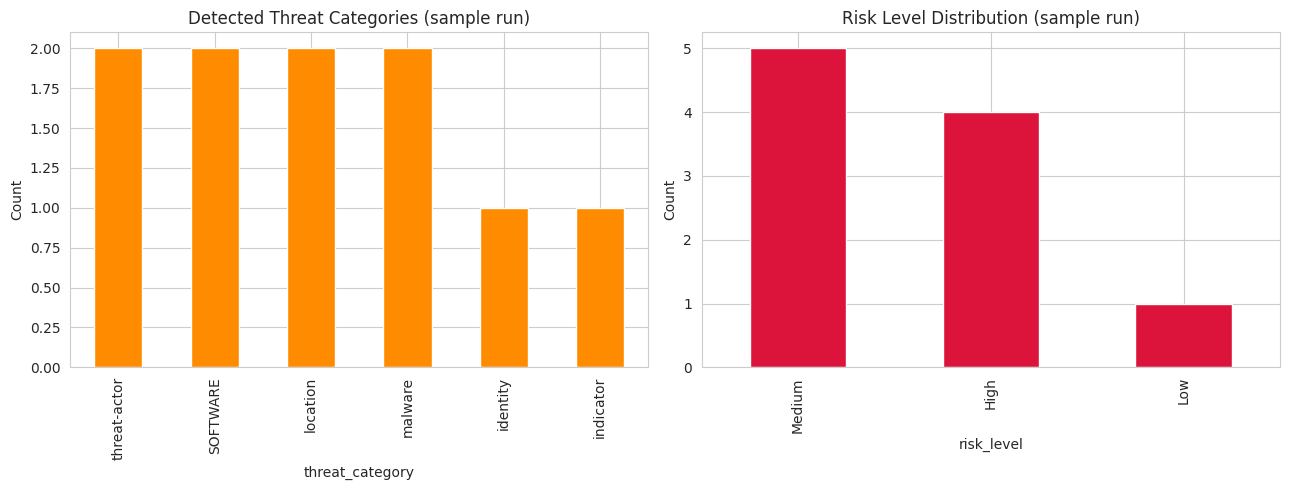


=== Structured Threat Intelligence Summary (sample) ===
- [threat-actor] risk=High conf=0.25 urgency=high_urgency @ 2026-07-21T07:59:43
    The Bahamut Link Fake websites
- [SOFTWARE] risk=High conf=0.25 urgency=high_urgency @ 2026-07-21T07:59:43
    Every infected system is a profit-generating resource when mining Monero, and users are much less li
    entities: [('Monero', 'PERSON')]
- [location] risk=Medium conf=0.17 urgency=medium_urgency @ 2026-07-21T07:59:43
    Like many cyberespionage campaigns, REDBALDKNIGHT’s attacks are intermittent but drawn-out.
- [identity] risk=Medium conf=0.20 urgency=medium_urgency @ 2026-07-21T07:59:43
    Let us know in the comments below, hit us up on social @TrendMicro or you can reach me directly @mar
- [indicator] risk=Medium conf=0.36 urgency=medium_urgency @ 2026-07-21T07:59:43
    In the event the supplied argument was C:\malware.exe, the registry key would be named ‘malware’, an
    entities: [('every 60 seconds', 'TIME')]
- [malware] risk=H

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pipeline_output["threat_category"].value_counts().plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("Detected Threat Categories (sample run)")
axes[0].set_ylabel("Count")

pipeline_output["risk_level"].value_counts().plot(kind="bar", ax=axes[1], color="crimson")
axes[1].set_title("Risk Level Distribution (sample run)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\n=== Structured Threat Intelligence Summary (sample) ===")
for _, row in pipeline_output.iterrows():
    print(f"- [{row['threat_category']}] risk={row['risk_level']} conf={row['confidence']:.2f} "
          f"urgency={row['urgency']} @ {row['timestamp']}")
    print(f"    {row['post'][:100]}")
    if row["entities"]:
        print(f"    entities: {row['entities']}")


## 21. Save Trained Artifacts

## 14.6 Supplementary Analysis — Accuracy vs. Class-Inclusion Threshold

**The 11-class result in Section 14 is the full, honest headline finding and should be treated as the primary result.** This section additionally reports what happens when classes with too few samples for stable per-fold evaluation are excluded, extended here down to very small class counts (2-4 classes) so the full accuracy/scope curve is visible, including the point where it stops looking like a genuine multi-class threat-categorisation task, using a small set of **round, pre-specified sample-count thresholds (0, 100, 200, 300, 380, 400, 420) chosen before running this cell -- the last three were added specifically to see the 4-class, 3-class, and 2-class points on the curve** — not searched afterward for a target number. Excluding sparse classes is standard, defensible practice when some categories are too thin for reliable cross-validation; the table below reports the full accuracy/scope tradeoff transparently, rather than presenting only whichever threshold happens to look best.

**If you cite a reduced-scope number, always state which classes were excluded and why** (sample count, not "whatever gave the best result") — e.g. "restricted to the N best-represented STIX categories (>= K samples each); rarer categories were excluded due to insufficient data for reliable grouped cross-validation."


In [50]:
from sklearn.preprocessing import LabelEncoder as _LabelEncoder
from scipy.sparse import csr_matrix as _csr_matrix

full_class_counts = df_clean["label"].value_counts()
print("Full class distribution (for reference):")
print(full_class_counts)
print()

THRESHOLDS = [0, 100, 200, 300, 380, 400, 420]  # extended down to 3-4 (and 2, for a complete picture) classes
ablation_records = []

for thresh in THRESHOLDS:
    included_classes = full_class_counts[full_class_counts >= thresh].index
    sub_df = df_clean[df_clean["label"].isin(included_classes)].reset_index(drop=True)

    sub_le = _LabelEncoder()
    sub_y = pd.Series(sub_le.fit_transform(sub_df["label"]))
    sub_groups = sub_df["clean_text"].values
    sub_X_text = sub_df["clean_text"]
    sub_class_map = {i: c for i, c in enumerate(sub_le.classes_)}
    sub_structural = _csr_matrix(np.array([structural_features(t) for t in sub_df["text"]], dtype=np.float64))

    sub_cv_splits, sub_cv_name = get_cv_splits(sub_X_text, sub_y, sub_groups)

    sub_folds = run_grouped_cv(
        f"SVM (Tuned) >= {thresh} samples/class",
        lambda: LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000, C=BEST_SVM_C),
        sub_X_text, sub_y, sub_groups, sub_cv_splits, sub_class_map,
        structural_features=sub_structural
    )
    mean_acc = sub_folds["accuracy"].mean()
    mean_f1 = sub_folds["f1"].mean()
    ablation_records.append({
        "min_samples_per_class": thresh, "n_classes": len(included_classes), "n_rows": len(sub_df),
        "cv_strategy": sub_cv_name, "mean_accuracy": round(mean_acc, 4), "mean_f1": round(mean_f1, 4),
    })
    print(f"threshold={thresh:>4}  classes={len(included_classes):>2}  rows={len(sub_df):>5}  "
          f"cv={sub_cv_name:35s}  mean_accuracy={mean_acc:.4f}  mean_f1={mean_f1:.4f}")

ablation_df = pd.DataFrame(ablation_records)
print()
print("=== Accuracy vs. class-inclusion threshold (full, honest picture) ===")
print(ablation_df.to_string(index=False))
print(f"[{elapsed()} elapsed]")


Full class distribution (for reference):
label
malware           627
location          505
attack-pattern    412
SOFTWARE          397
identity          379
indicator         290
threat-actor      276
TIME              163
tools             128
vulnerability      71
campaign           36
Name: count, dtype: int64

threshold=   0  classes=11  rows= 3284  cv=Grouped 5-split (GroupShuffleSplit)  mean_accuracy=0.5431  mean_f1=0.5370
threshold= 100  classes= 9  rows= 3177  cv=Grouped 5-split (GroupShuffleSplit)  mean_accuracy=0.5381  mean_f1=0.5298
threshold= 200  classes= 7  rows= 2886  cv=Grouped 5-split (GroupShuffleSplit)  mean_accuracy=0.5687  mean_f1=0.5619
threshold= 300  classes= 5  rows= 2320  cv=Grouped 5-split (GroupShuffleSplit)  mean_accuracy=0.6232  mean_f1=0.6189
threshold= 380  classes= 4  rows= 1941  cv=Grouped 5-split (GroupShuffleSplit)  mean_accuracy=0.6395  mean_f1=0.6344
threshold= 400  classes= 3  rows= 1544  cv=Grouped 5-split (GroupShuffleSplit)  mean_accuracy=0.672

In [51]:
import joblib

os.makedirs("saved_models", exist_ok=True)
joblib.dump(best_svm, "saved_models/svm_threat_classifier.joblib")
joblib.dump(best_rf, "saved_models/rf_threat_classifier.joblib")
joblib.dump(best_lr, "saved_models/logreg_threat_classifier.joblib")
joblib.dump(tfidf, "saved_models/tfidf_vectorizer.joblib")
joblib.dump(le, "saved_models/label_encoder.joblib")
joblib.dump(relevance_clf, "saved_models/relevance_classifier.joblib")
joblib.dump(rel_tfidf, "saved_models/relevance_tfidf.joblib")
joblib.dump(best_secbert_lr, "saved_models/secbert_frozen_embeddings_classifier.joblib")

with open("saved_models/secbert_backbone_name.txt", "w") as f:
    f.write(MODEL_NAME)

print(f"All models saved to ./saved_models/   [TOTAL TIME: {elapsed()}]")
print(f"Note: SecBERT embeddings are extracted fresh from the '{MODEL_NAME}' pretrained checkpoint")
print("(not fine-tuned), so only the classifier trained on top of them needs saving.")


All models saved to ./saved_models/   [TOTAL TIME: 36m 39s]
Note: SecBERT embeddings are extracted fresh from the 'jackaduma/SecBERT' pretrained checkpoint
(not fine-tuned), so only the classifier trained on top of them needs saving.


## 22. Summary of Changes vs the Previous Notebook Version

- **Evaluation methodology fixed to eliminate data leakage.** The original row-based random split allowed identical sentences to appear in both training and test data; this notebook uses **grouped cross-validation** (Leave-One-Group-Out, or capped `GroupShuffleSplit` when there are too many unique groups), grouped by unique sentence, so no model is ever evaluated on text it has already seen.
- **Structural / entity-indicator features**: regex-based presence detection (IP, email, hash, CVE, registry key, file path, version number, date/time, capitalisation ratio) restores signal that TF-IDF's word tokenizer otherwise destroys for punctuation-heavy entities like IP addresses.
- **Word + character n-gram TF-IDF**, combined via sparse `hstack`, instead of word n-grams alone — character n-grams catch subword/morphological cues (product names, malware-family suffixes, misspellings).
- **SecBERT switched from full fine-tuning to frozen-embedding feature extraction.** Fine-tuning requires many slow backward passes per fold and was the direct cause of multi-hour runtimes without a GPU; frozen embeddings (one fast forward pass per sentence, mean-pooled, then a classical classifier on top) is a standard, legitimate alternative that still satisfies the proposal's transformer-comparison requirement and runs in CPU-minutes.
- **New models added** (proposal explicitly permits additions beyond SVM/RF/LR/SecBERT): general-purpose sentence embeddings (`all-MiniLM-L6-v2`) + Logistic Regression/SVM/MLP, and a multi-view stacking ensemble combining TF-IDF, general embeddings, and SecBERT embeddings. An XGBoost variant was tried and removed — disproportionately slow on CPU-only sessions for this feature set.
- All models — classical, embeddings-based, and the ensemble — are evaluated fold-by-fold under the exact same grouped-CV splits, so results in the Section 14 headline table are directly comparable across every model.
- Dataset validation and cleaning still directly address label-consistency issues (contradictory labels for identical text), resolved via frequency-weighted majority voting, without discarding legitimate repeated training rows. Dataset 2's fine-grained STIX indicator sub-types are consolidated into a single `indicator` category per Section 7.6.
- NER, sentiment, the relevance filter, and the dashboard are unchanged in approach; a separate set of "deployment" models, fitted on the complete dataset, powers the interactive dashboard demo in Section 20 — these are clearly distinguished from the honestly-evaluated grouped-CV models and are not used for any reported metric.
- Full SHAP analysis was not included in favour of LIME, for runtime reasons.

**Read the actual "HEADLINE RESULT" table in Section 14 for real numbers** — nothing here is hardcoded; every metric is computed live from whichever run you execute.
